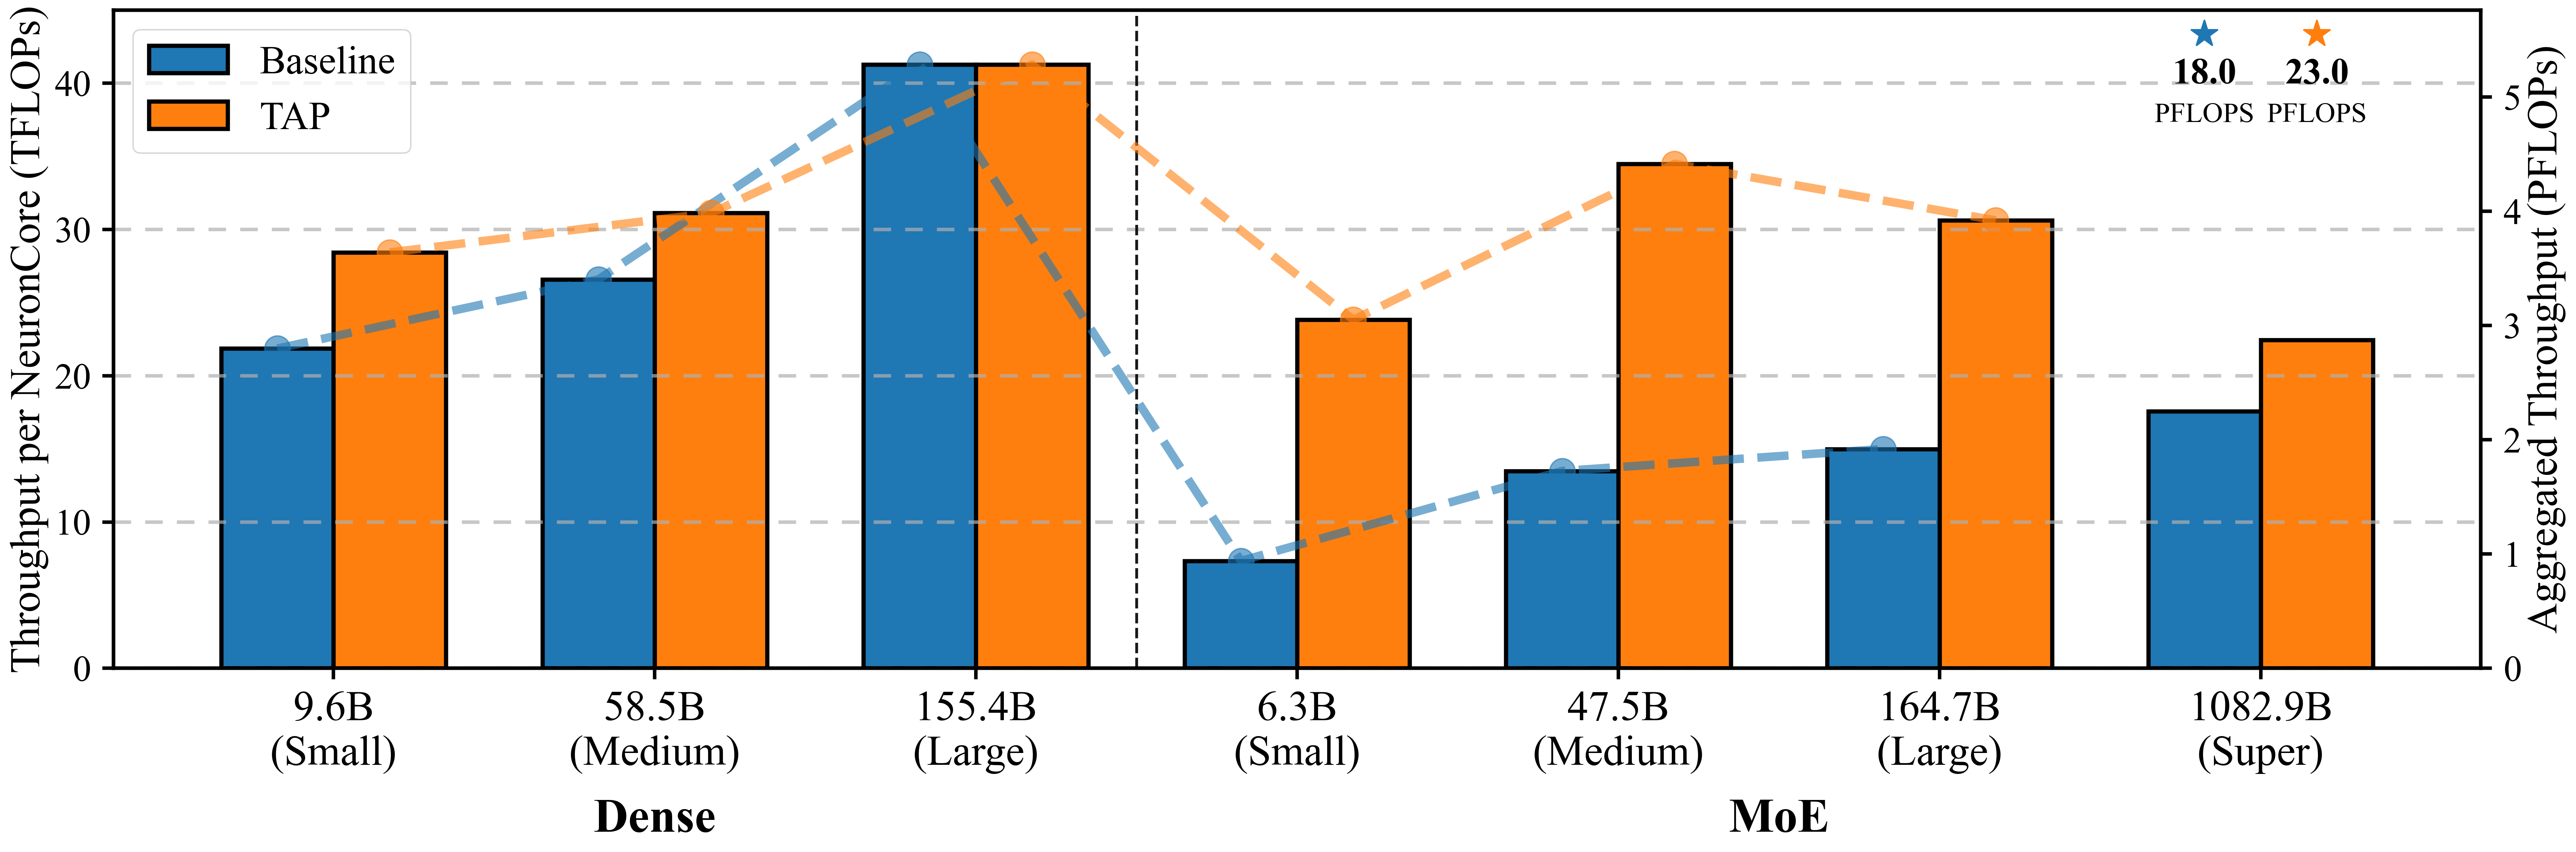

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl

# mpl.rcParams["svg.fonttype"] = "none"

# 4 categories on the x-axis
categories = ["9.6B\n(Small)", "58.5B\n(Medium)", "155.4B\n(Large)"]
categories += [
    "6.3B\n(Small)",
    "47.5B\n(Medium)",
    "164.7B\n(Large)",
    "1082.9B\n(Super)",
]

# Two bar-series (2 bars per category)
baseline = [21.86, 26.59, 41.27]
ours = [
    28.43,
    31.12,
    # 35.89
    41.27,
]

baseline += [7.34, 13.49, 14.99, 17.57]
ours += [23.83, 34.49, 30.62, 22.44]

# TODO adjust for super
baseline_agg = [i * 128 / 1000 for i in baseline]
baseline_agg[6] = baseline[6] * 1024 / 1000
baseline_agg[6] = np.nan
ours_agg = [i * 128 / 1000 for i in ours]
ours_agg[6] = ours[6] * 1024 / 1000
ours_agg[6] = np.nan

x = np.arange(len(categories))  # [0,1,2,3]
width = 0.35  # width of each bar

plt.rcParams.update(
    {
        "font.size": 26,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

fig, ax = plt.subplots(figsize=(26, 9), dpi=300)
ax2 = ax.twinx()
ax.bar(
    x - width / 2,
    baseline,
    width,
    label="Baseline",
    edgecolor="black",
    linewidth=3,
)
ax.bar(
    x + width / 2,
    ours,
    width,
    label="TAP",
    edgecolor="black",
    linewidth=3,
)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=30)
ax.locator_params(axis="y", nbins=5)
ax.set_ylabel("Throughput per NeuronCore (TFLOPs)", fontsize=30)
# ax.set_title("Grouped Bar Chart (4 categories, 2 bars each)")
ax.legend(fontsize=28, loc="upper left")

ax.tick_params(axis="y", length=8, pad=8)
ax.tick_params(axis="x", length=8, pad=8)

leftmax = 45
rightmax = (leftmax * 128) / 1000
ax.set_ylim(0, leftmax)  # Adjust based on your max aggregated data
ax2.set_ylabel("Aggregated Throughput (PFLOPs)", fontsize=30)
ax2.set_ylim(0, rightmax)  # Adjust based on your max aggregated data


(l1,) = ax2.plot(
    x - width / 2,
    baseline_agg,
    linestyle="--",
    linewidth=6,
    marker="o",
    markersize=18,
    alpha=0.6,
)
(l2,) = ax2.plot(
    x + width / 2,
    ours_agg,
    linestyle="--",
    linewidth=6,
    marker="o",
    markersize=18,
    alpha=0.6,
)
# ax2.tick_params(axis='y', length=1, width=100000)
# for spine in ax.spines.values():
#     spine.set_linewidth(2)

separator_x = (x[2] + x[3]) / 2
ax.axvline(separator_x, linestyle="--", color="black", linewidth=2, alpha=0.9)
group1_center = np.mean(x[:3])
group2_center = np.mean(x[3:])


# dot + number logic

super_idx = 6
baselineNum = baseline[super_idx] * 1024 / 1000
tapNum = ours[super_idx] * 1024 / 1000

real_val_b = baseline[super_idx] * 1024 / 1000
real_val_o = ours[super_idx] * 1024 / 1000

visual_val_b = baseline[super_idx] * 128 / 1000 + 3.3
visual_val_o = ours[super_idx] * 128 / 1000 + 3.3

visual_val_o = visual_val_b
ax2.plot(
    x[super_idx] - width / 2,
    visual_val_b,
    marker="*",
    markersize=20,
    color=l1.get_color(),
)
ax2.plot(
    x[super_idx] + width / 2,
    visual_val_o,
    marker="*",
    markersize=20,
    color=l2.get_color(),
)
ax2.text(
    x[super_idx] - width / 2,
    visual_val_b - 0.6,
    "PFLOPS",
    ha="center",
    va="top",
    fontsize=20,
    fontweight="normal",
    rotation=0,
)
ax2.text(
    x[super_idx] + width / 2,
    visual_val_o - 0.6,
    "PFLOPS",
    ha="center",
    va="top",
    fontsize=20,
    fontweight="normal",
    rotation=0,
)
# 4. Add the text labels above the dots
# We use the 'real_val' for the text, but place it at 'visual_val' height
ax2.text(
    x[super_idx] - width / 2,
    visual_val_b - 0.5,
    f"{real_val_b:.1f}",
    ha="center",
    va="bottom",
    fontsize=26,
    fontweight="bold",
    rotation=0,
)
ax2.text(
    x[super_idx] + width / 2,
    visual_val_o - 0.5,
    f"{real_val_o:.1f}",
    ha="center",
    va="bottom",
    fontsize=26,
    fontweight="bold",
    rotation=0,
)

ax2.tick_params(axis="y", length=8, pad=8)

ax.text(
    group2_center,
    -0.20,
    "MoE",
    ha="center",
    va="top",
    fontsize=34,
    fontweight="bold",
    transform=ax.get_xaxis_transform(),
)
ax.text(
    group1_center,
    -0.20,
    "Dense",
    ha="center",
    va="top",
    fontsize=34,
    fontweight="bold",
    transform=ax.get_xaxis_transform(),
)

ax.grid(axis="y", linestyle=(0, (5, 4)), linewidth=2.5, alpha=0.7, zorder=0)
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()

speedups = [s2 / s1 for s1, s2 in zip(baseline, ours) if s1 > 0]
# print(f"Speedups: {speedups}")
# print(f"Max Speedup: {max(speedups):.2f}x")

fig.savefig(
    "EvaluationMainResults.pdf",
    # format="svg",
    bbox_inches="tight",
    # transparent=True,
    dpi=300,
)

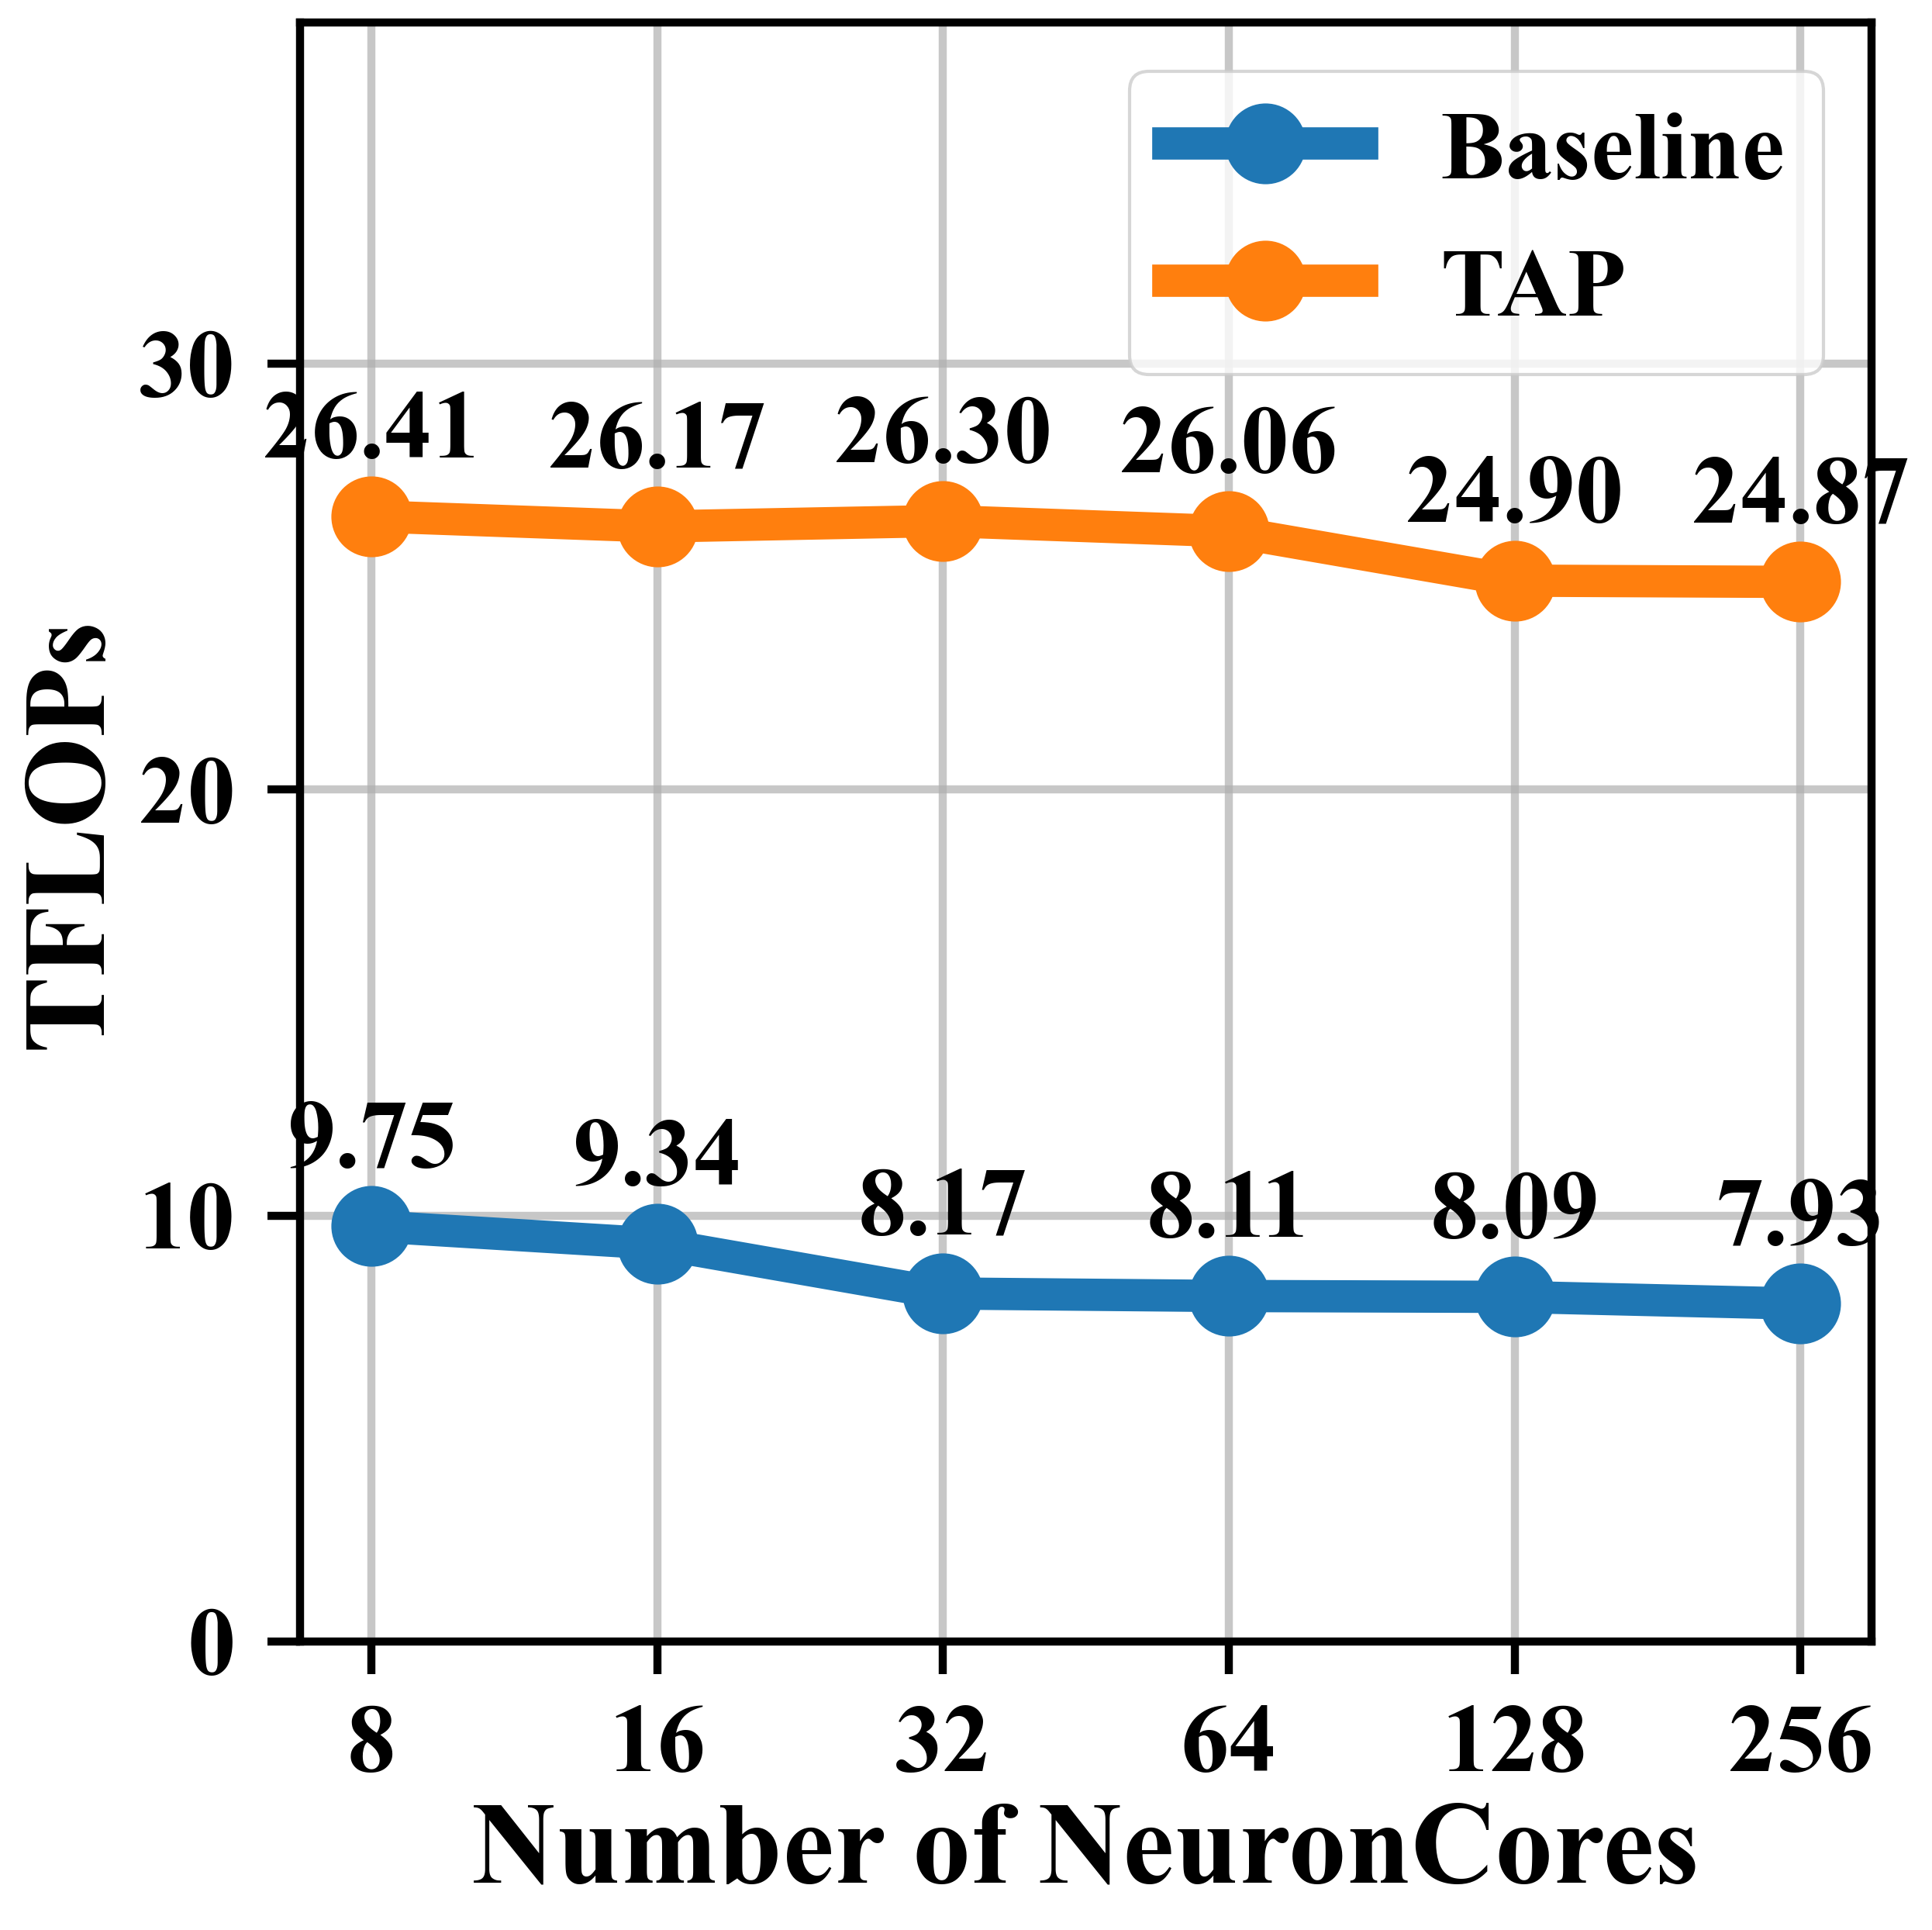

In [244]:
import matplotlib.pyplot as plt

import matplotlib as mpl

# mpl.rcParams["svg.fonttype"] = "none"

# X axis (e.g., months)
x = [8, 16, 32, 64, 128, 256]

# Two categories (two lines)
baseline = [9.75, 9.34, 8.17, 8.11, 8.09, 7.93]
ours = [26.41, 26.17, 26.30, 26.06, 24.90, 24.87]

plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

fig, ax = plt.subplots(figsize=(9, 9), dpi=300)

ax.plot(
    x,
    baseline,
    label="Baseline",
    linewidth=10,
    marker="o",
    markersize=24,
)
ax.plot(
    x,
    ours,
    label="TAP",
    linewidth=10,
    marker="o",
    markersize=24,
)
ax.set_xscale("log", base=2)
ax.set_xticks(x)
ax.set_xticklabels(x, fontweight="bold")
ax.set_ylim(0, 38)
ax.set_yticks([0, 10, 20, 30])
ax.set_yticklabels([0, 10, 20, 30], fontweight="bold")
# ax.set_ylim(0, 30)

ax.tick_params(axis="y", length=10, pad=10)
ax.tick_params(axis="x", length=10, pad=10)


def label_points(xs, ys, fmt="{:.2f}", dy=12):
    for xi, yi in zip(xs, ys):
        ax.annotate(
            fmt.format(yi),
            (xi, yi),
            textcoords="offset points",
            xytext=(0, dy),  # (x_offset, y_offset) in points
            ha="center",
            va="bottom",
            clip_on=False,
            fontsize=30,
            fontweight="bold",
            # zorder=0,
        )


label_points(x, baseline, dy=12)
label_points(x, ours, dy=12)

ax.set_yticks([0, 10, 20, 30])

# plt.title("Line Chart with Two Categories")
ax.set_xlabel("Number of NeuronCores", fontsize=36, fontweight="bold")
ax.set_ylabel("TFLOPs", fontsize=36, fontweight="bold")
ax.legend(loc="upper right", prop={"weight": "bold"})
# ax.legend()
ax.grid(True, linestyle="-", linewidth=2.5, alpha=0.7)
plt.tight_layout()
plt.show()

fig.savefig(
    "EvaluationWeakScaling.pdf",
    # format="svg",
    bbox_inches="tight",
    # transparent=True,
    dpi=300,
)

In [3]:
import matplotlib.font_manager as fm
from matplotlib import pyplot as plt

print("rcParams font.family =", plt.rcParams["font.family"])
print("rcParams font.serif  =", plt.rcParams["font.serif"])

fp = fm.FontProperties(family="Times New Roman")
print("resolved font file =", fm.findfont(fp))

rcParams font.family = ['serif']
rcParams font.serif  = ['Times New Roman', 'Times', 'Nimbus Roman']
resolved font file = /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf


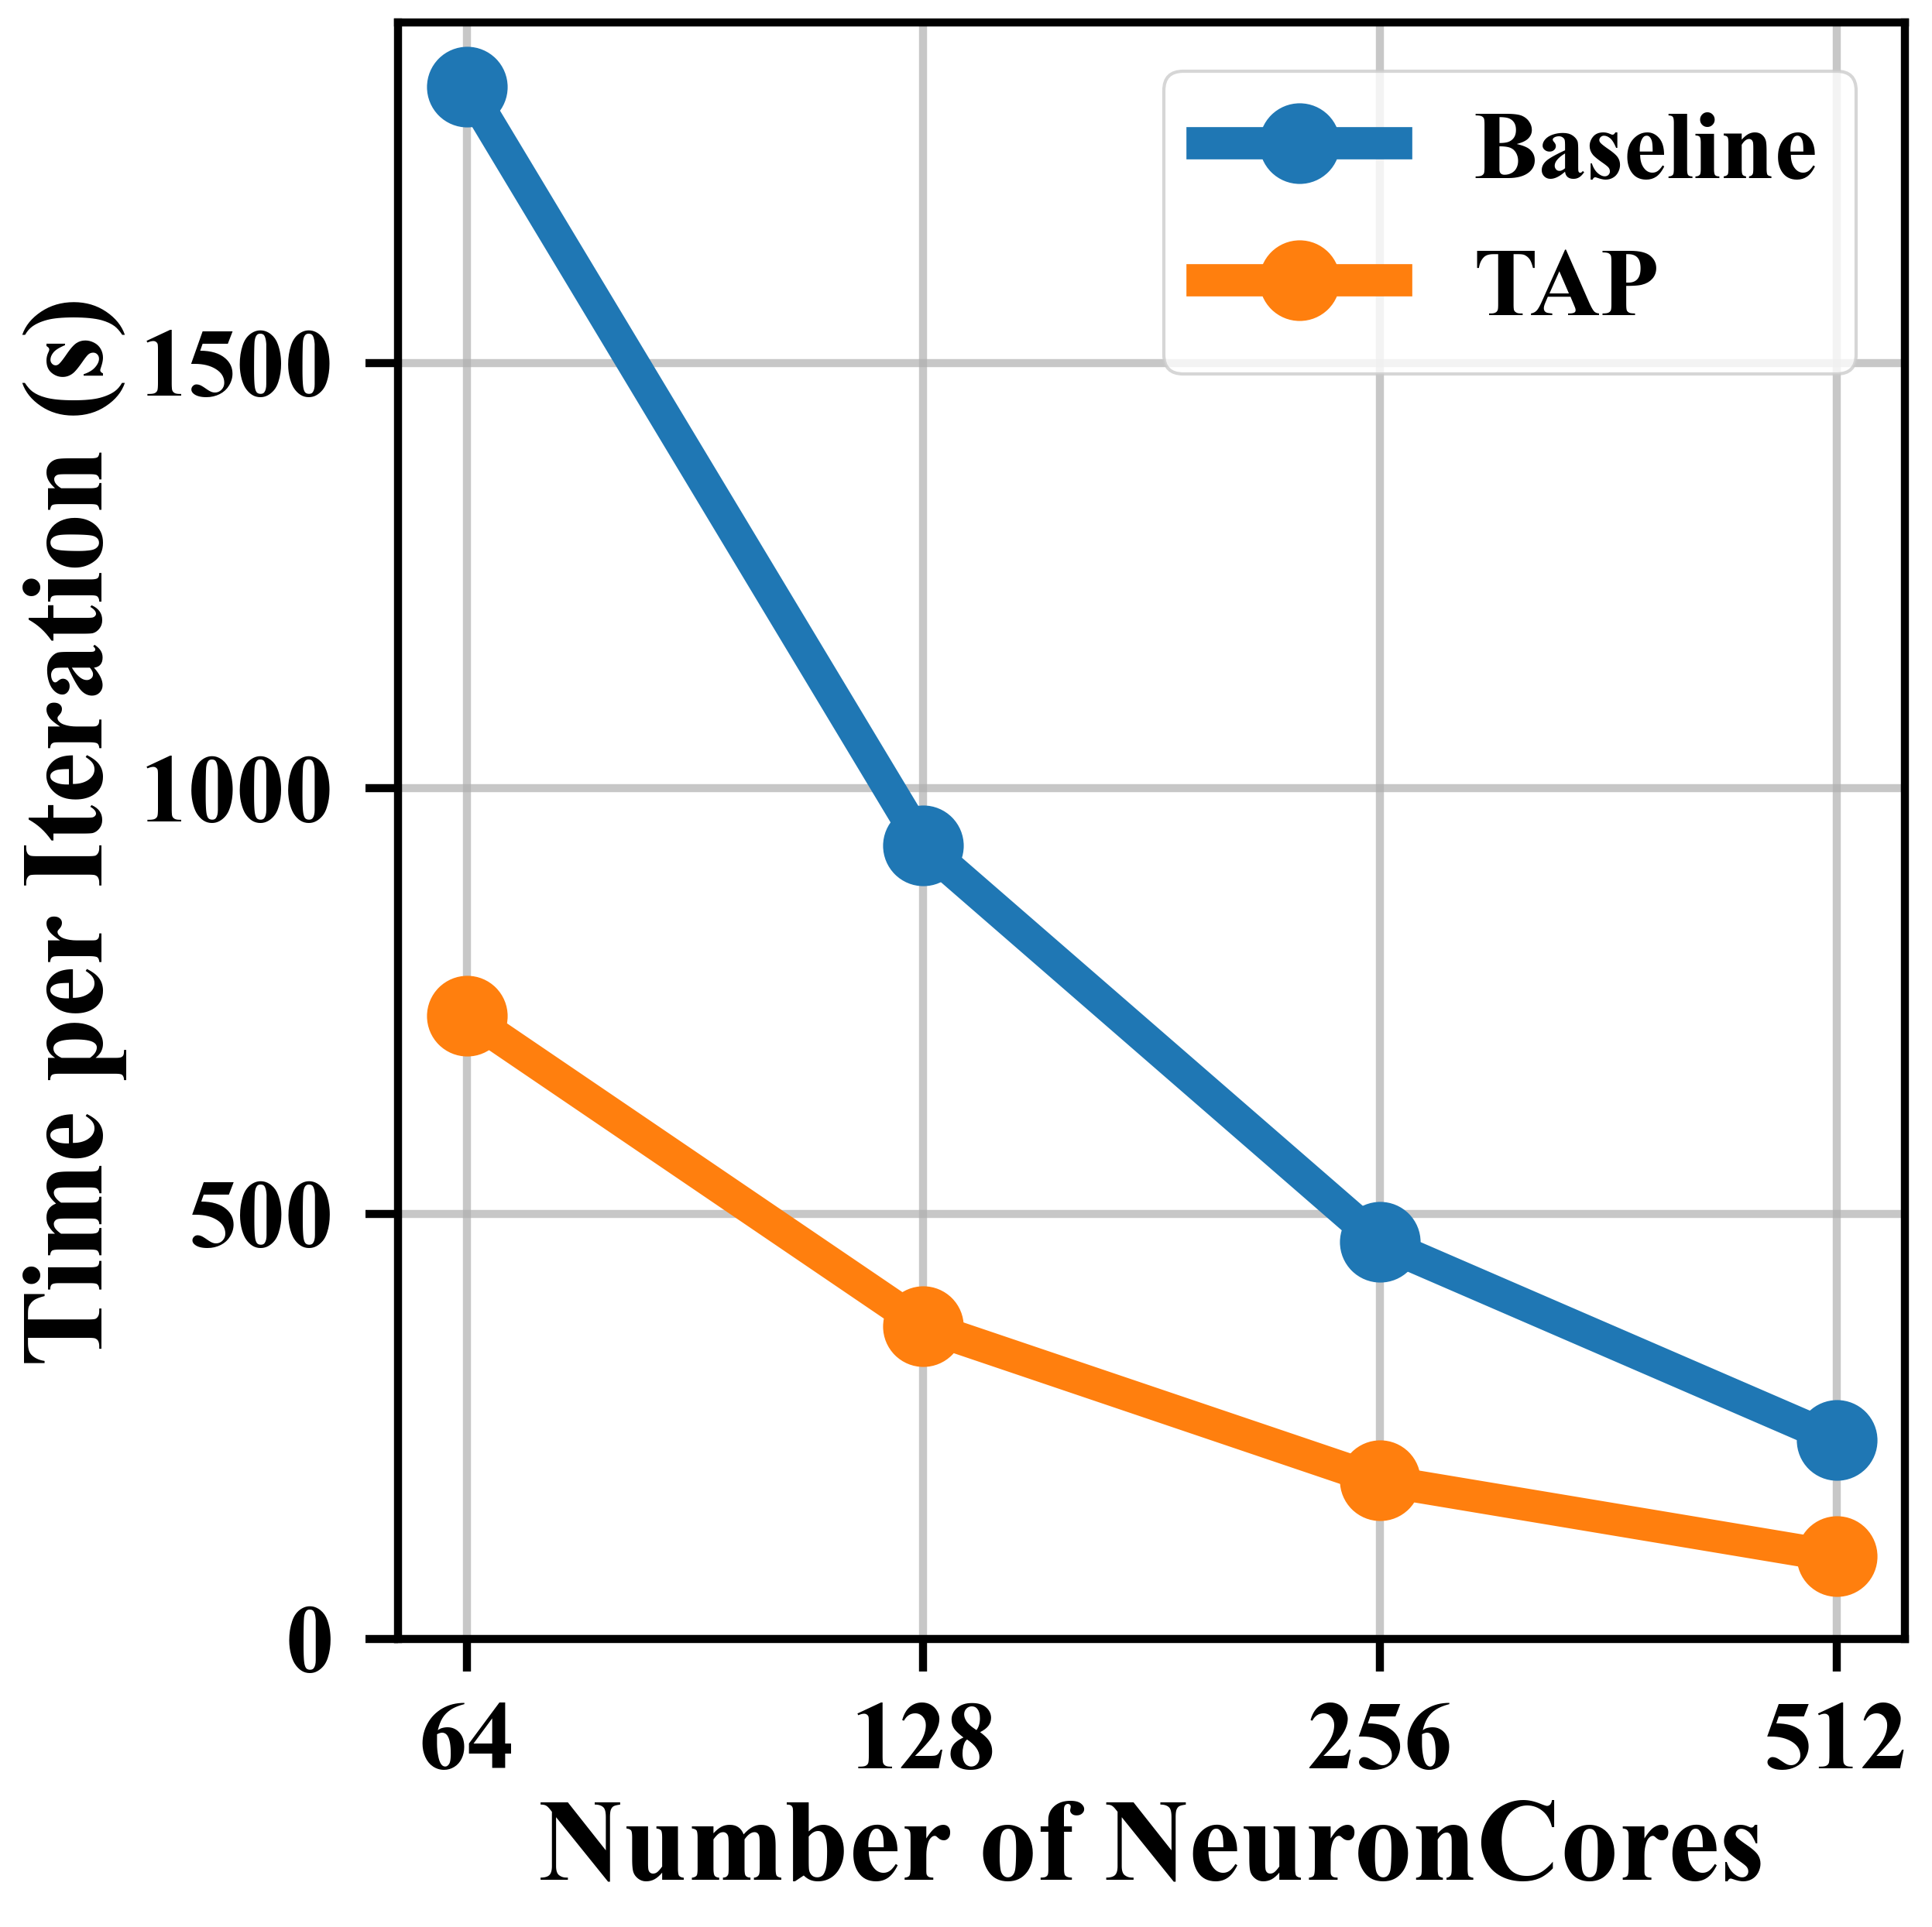

In [243]:
import matplotlib.pyplot as plt

import matplotlib as mpl

# mpl.rcParams["svg.fonttype"] = "none"

# X axis (e.g., months)
x = [64, 128, 256, 512]

# Two categories (two lines)
baseline = [1824.46, 932.56, 466.54, 234.24]
ours = [732.78, 368.03, 186.46, 97.00]

plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

fig, ax = plt.subplots(figsize=(9, 9), dpi=300)

ax.plot(
    x,
    baseline,
    label="Baseline",
    linewidth=10,
    marker="o",
    markersize=24,
)
ax.plot(
    x,
    ours,
    label="TAP",
    linewidth=10,
    marker="o",
    markersize=24,
)
ax.set_xscale("log", base=2)
ax.set_xticks(x)
ax.set_xticklabels(x, fontweight="bold")
ax.set_ylim(0, 1900)

y = [0, 500, 1000, 1500]
ax.set_yticks(y)
ax.set_yticklabels(y, fontweight="bold")

ax.tick_params(axis="y", length=10, pad=10)
ax.tick_params(axis="x", length=10, pad=10)


def label_points(xs, ys, fmt="{:.2f}", dy=12):
    for xi, yi in zip(xs, ys):
        ax.annotate(
            fmt.format(yi),
            (xi, yi),
            textcoords="offset points",
            xytext=(0, dy),  # (x_offset, y_offset) in points
            ha="center",
            va="bottom",
            clip_on=False,
            fontsize=30,
            # zorder=0,
        )


# label_points(x, baseline, dy=12)
# label_points(x, ours, dy=12)


# plt.title("Line Chart with Two Categories")
ax.set_xlabel("Number of NeuronCores", fontsize=36, fontweight="bold")
ax.set_ylabel("Time per Iteration (s)", fontsize=36, fontweight="bold")
ax.legend(loc="upper right", prop={"weight": "bold"})
ax.grid(True, linestyle="-", linewidth=2.5, alpha=0.7)
plt.tight_layout()
plt.show()

fig.savefig(
    "EvaluationStrongScaling.pdf",
    # format="svg",
    bbox_inches="tight",
    # transparent=True,
    dpi=300,
)

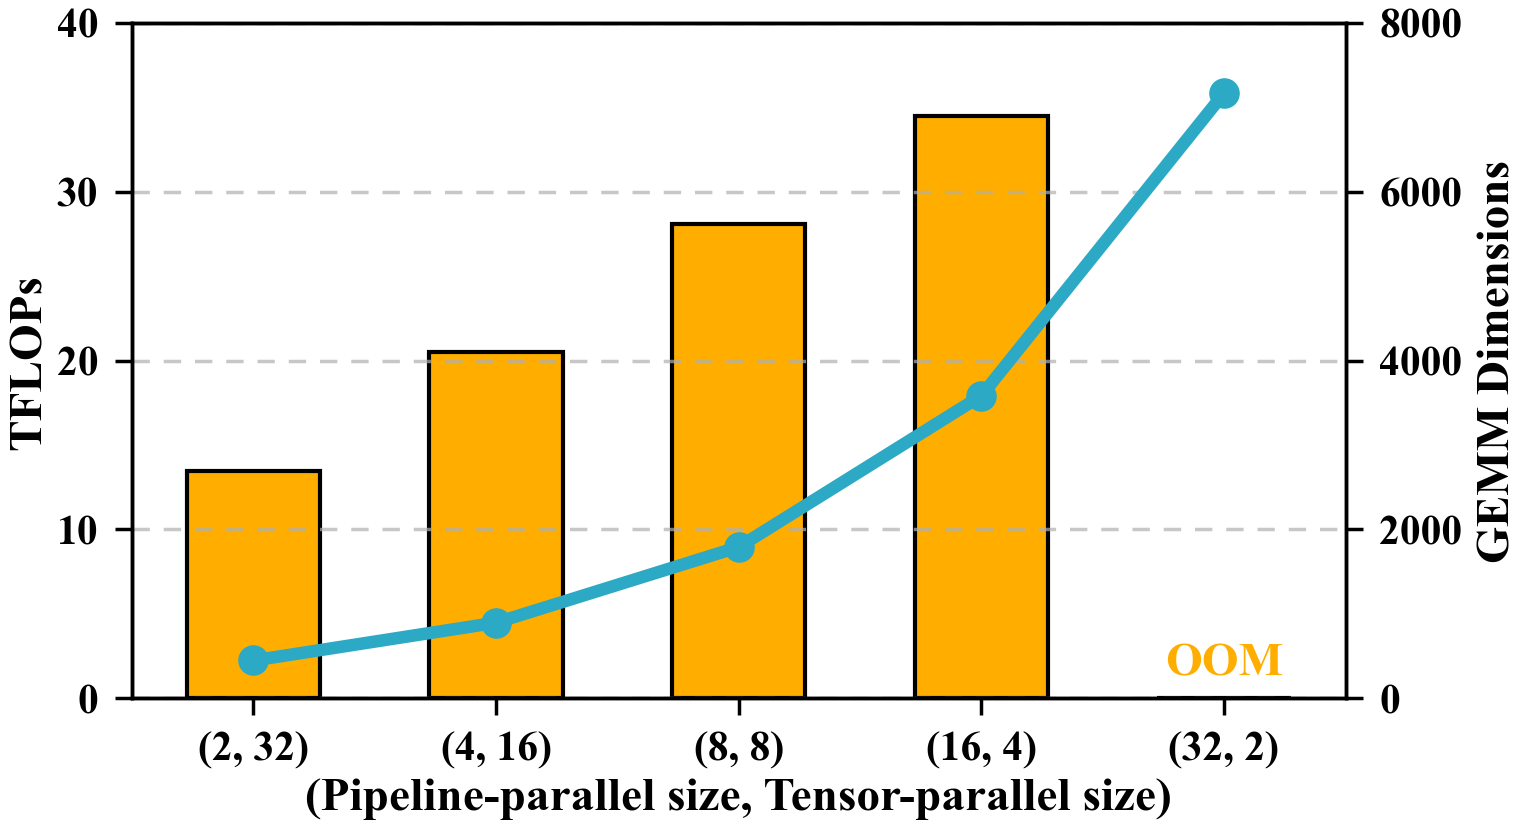

In [88]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

# ---------------------------
# Fake example data
# ---------------------------
x_labels = ["(2, 32)", "(4, 16)", "(8, 8)", "(16, 4)", "(32, 2)"]
x = np.arange(len(x_labels))

# Left Y-axis (bar)
bar_values = np.array([13.49, 20.51, 28.07, 34.49, 0])

# Right Y-axis (line) — two categories
line_cat_a = np.array([448, 896, 1792, 3584, 7168])
# line_cat_b = np.array([2.2, 1.9, 2.6, 2.1, 2.9])
# ---------------------------
# Plot
# ---------------------------
fig, ax_left = plt.subplots(figsize=(16, 9))

# Bars (put behind)
bars = ax_left.bar(
    x,
    bar_values,
    width=0.55,
    edgecolor="black",
    linewidth=3,
    # alpha=0.6,  # <-- makes overlap less confusing
    zorder=1,  # <-- bars behind
    # color=l2.get_color(),
    color="#ffae00",
    # label="Throughput per NeuronCore (TFLOPs)",
)
ax_left.set_ylabel(
    # "Throughput per \nNeuronCore (TFLOPs)",
    "TFLOPs",
    fontsize=34,
    fontweight="bold",
)
ax_left.set_yticks([0, 10, 20, 30, 40])
ax_left.set_yticklabels([0, 10, 20, 30, 40], fontsize=30, fontweight="bold")
ax_left.set_xlabel(
    "(Pipeline-parallel size, Tensor-parallel size)",
    fontsize=34,
    labelpad=6,
    fontweight="bold",
)
ax_left.set_xticks(x)
ax_left.set_xticklabels(x_labels, fontsize=30, fontweight="bold")

ax_left.tick_params(axis="y", length=12, pad=12)
ax_left.tick_params(axis="x", length=12, pad=12)
ax_left.set_ylim(0, 40)

# Grid behind everything
# ax_left.grid(True, axis="y", alpha=0.3, zorder=0)
ax_left.grid(
    axis="y",
    linestyle=(0, (5, 4)),
    linewidth=2.5,
    alpha=0.7,
    zorder=0,
)

# Right axis (lines)
ax_right = ax_left.twinx()

# Make the right axis draw ON TOP of the left axis artists
ax_right.set_zorder(ax_left.get_zorder() + 1)
ax_right.patch.set_visible(False)  # don't cover the bars with a white background

(line1,) = ax_right.plot(
    x,
    line_cat_a,
    marker="o",
    linewidth=9,
    markersize=21,
    zorder=3,
    label="Line category A",
    # color=l2.get_color(),
    color="#2ca9c4",
)
# line2, = ax_right.plot(
#     x, line_cat_b, marker="s", linewidth=2.5, zorder=3, label="Line category B"
# )
ax_right.set_ylabel(
    "GEMM Dimensions",
    fontsize=34,
    labelpad=12,
    fontweight="bold",
)
ax_right.set_yticks([0, 2000, 4000, 6000, 8000])
ax_right.set_yticklabels(
    [0, 2000, 4000, 6000, 8000],
    fontsize=30,
    fontweight="bold",
)
ax_right.tick_params(axis="y", length=12, pad=12)
ax_right.set_ylim(0, 8000)

ax_left.text(
    x[-1], 0.8, "OOM",            # 0.8 可以按你想要的离 x 轴高度微调
    ha="center", va="bottom",
    fontsize=34, fontweight="bold",
    zorder=4,
    color=bars.get_children()[-1].get_facecolor(),  # same color as the last bar
)

# plt.title("Two Y-Axes: Bars (Left) + Two-Line Categories (Right)")

# Combined legend
# handles_left, labels_left = ax_left.get_legend_handles_labels()
# handles_right, labels_right = ax_right.get_legend_handles_labels()
# ax_left.legend(handles_left + handles_right, labels_left + labels_right, loc="upper left")

plt.tight_layout()
plt.show()

fig.savefig(
    "EvaluationTpVsPp.pdf",
    # format="svg",
    bbox_inches="tight",
    # transparent=True,
    dpi=300,
)

In [ ]:
import os
from tbparse import SummaryReader
import pandas as pd
import matplotlib.pyplot as plt


def load_df(exp: int):
    log_dir = "/fsx/linshuy2/neuronx-distributed-training/examples/nemo_experiments/hf_mixtral/"
    experiment = str(exp)

    if not os.path.exists('./df_storage/'):
        os.makedirs('./df_storage/')

    df = None 
    try:
        df = pd.read_pickle(f'./df_storage/{str(experiment)}Dataframe.pkl')
    except FileNotFoundError: 
        reader = SummaryReader(log_dir + experiment, extra_columns={'wall_time', 'dir_name', 'file_name'})
        df = reader.scalars
        df.to_pickle(f'./df_storage/{str(experiment)}Dataframe.pkl')

    return df

df = load_df(286)
other_df = load_df(288)

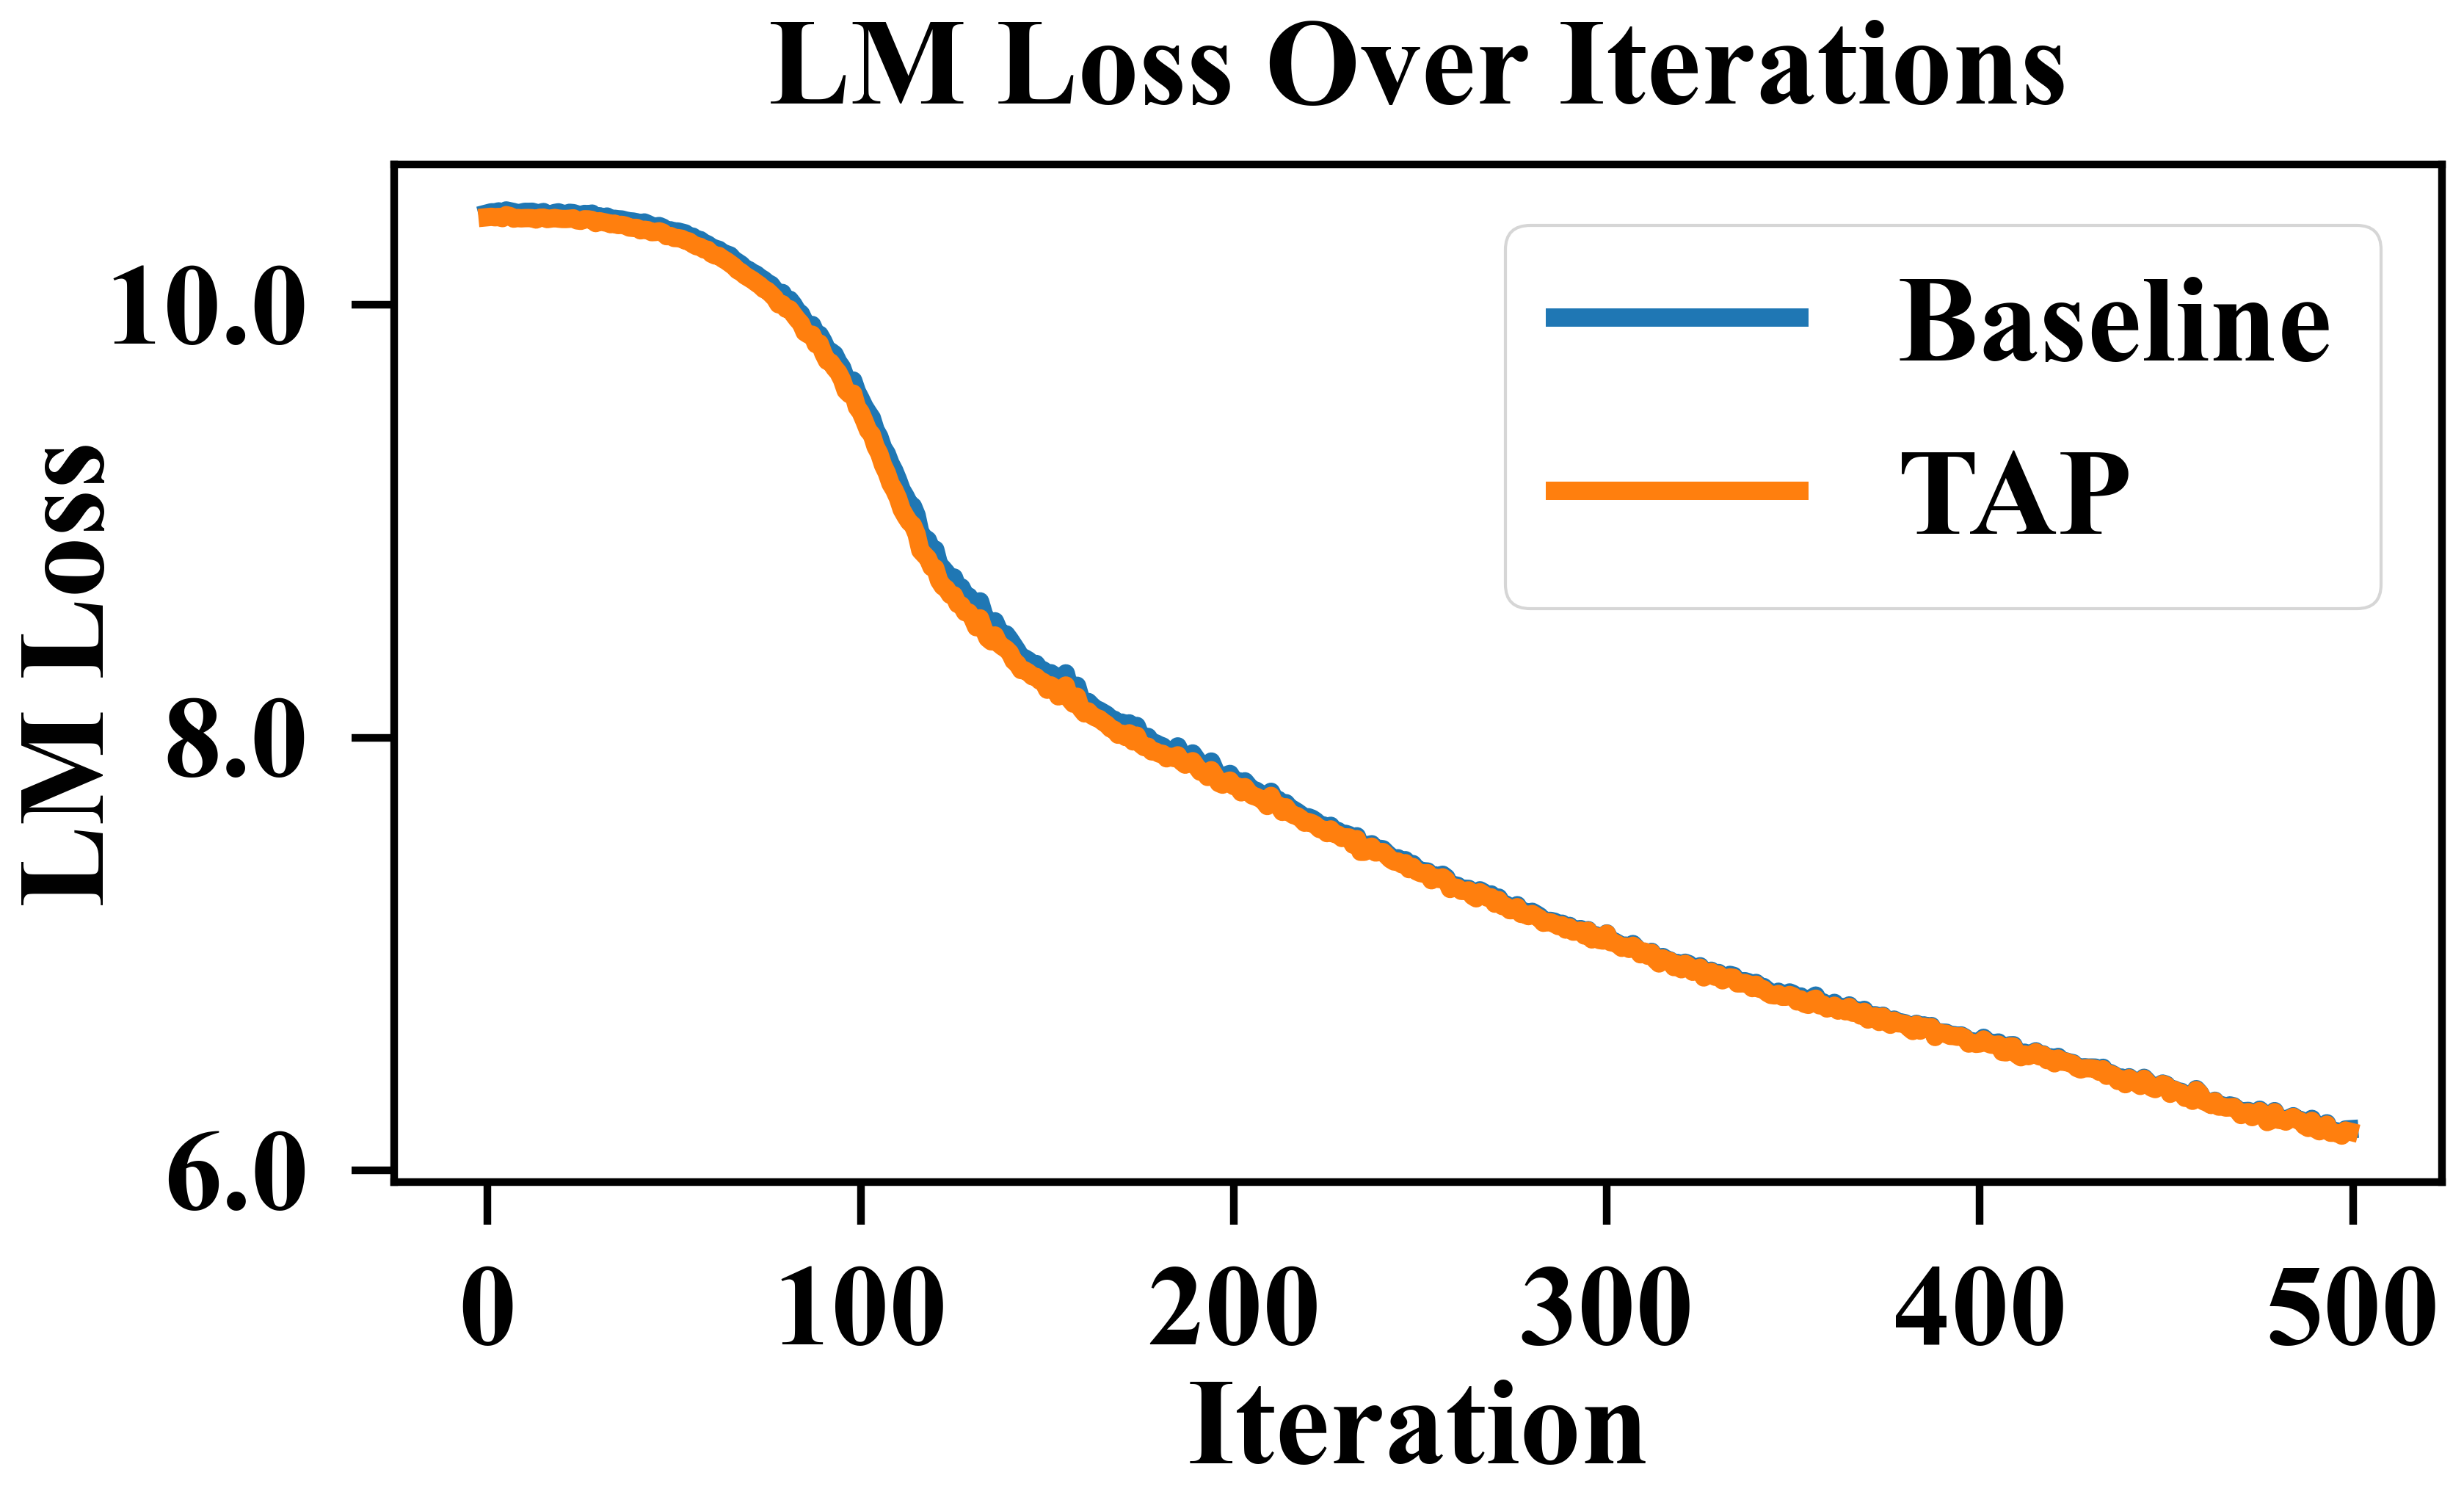

In [239]:
plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

first_n = 500


loss_cond = df["tag"] == "reduced_train_loss"
df_loss = df[loss_cond].copy()
df_loss = df_loss.sort_values(by="wall_time")

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

other_loss_cond = other_df["tag"] == "reduced_train_loss"
other_df_loss = other_df[other_loss_cond].copy()
other_df_loss = other_df_loss.sort_values(by="wall_time")

ax.plot(
    other_df_loss["step"][:first_n],
    other_df_loss["value"][:first_n],
    # marker='o',
    linestyle="-",
    label="Baseline",
    linewidth=6,
)

ax.plot(
    df_loss["step"][:first_n],
    df_loss["value"][:first_n],
    # marker='o',
    linestyle="-",
    label="TAP",
    linewidth=6,
)

ax.set_title(f"LM Loss Over Iterations", fontsize=40, fontweight="bold", pad=20)
ax.set_xlabel(
    "Iteration",
    fontsize=40,
    fontweight="bold",
)
ax.set_ylabel(
    "LM Loss",
    fontsize=40,
    fontweight="bold",
    labelpad=-8,
)
# x tick label bold
ax.set_xticks(
    [0, 100, 200, 300, 400, 500],
)
ax.set_xticklabels(
    [0, 100, 200, 300, 400, 500],
    fontsize=38,
    fontweight="bold",
)
# y tick label bold, only show 6.0, 8.0, 10.0 in .0 format
ax.set_yticks(
    [6.0, 8.0, 10.0],
)
ax.set_yticklabels(
    [6.0, 8.0, 10.0],
    fontsize=38,
    fontweight="bold",
)
# plt.grid(True, linestyle='--', alpha=0.7)
ax.tick_params(axis="y", length=14, pad=14)
ax.tick_params(axis="x", length=14, pad=14)
ax.legend(
    # fontsize=40,
    loc="upper right",
    prop={"weight": "bold", "size": 40},
)
# plt.savefig(f'./counter_averages/{args.folder}TrainingLoss.png')
plt.show()

fig.savefig(
    "EvaluationLossCurve.pdf",
    # format="svg",
    bbox_inches="tight",
    # transparent=True,
    dpi=300,
)

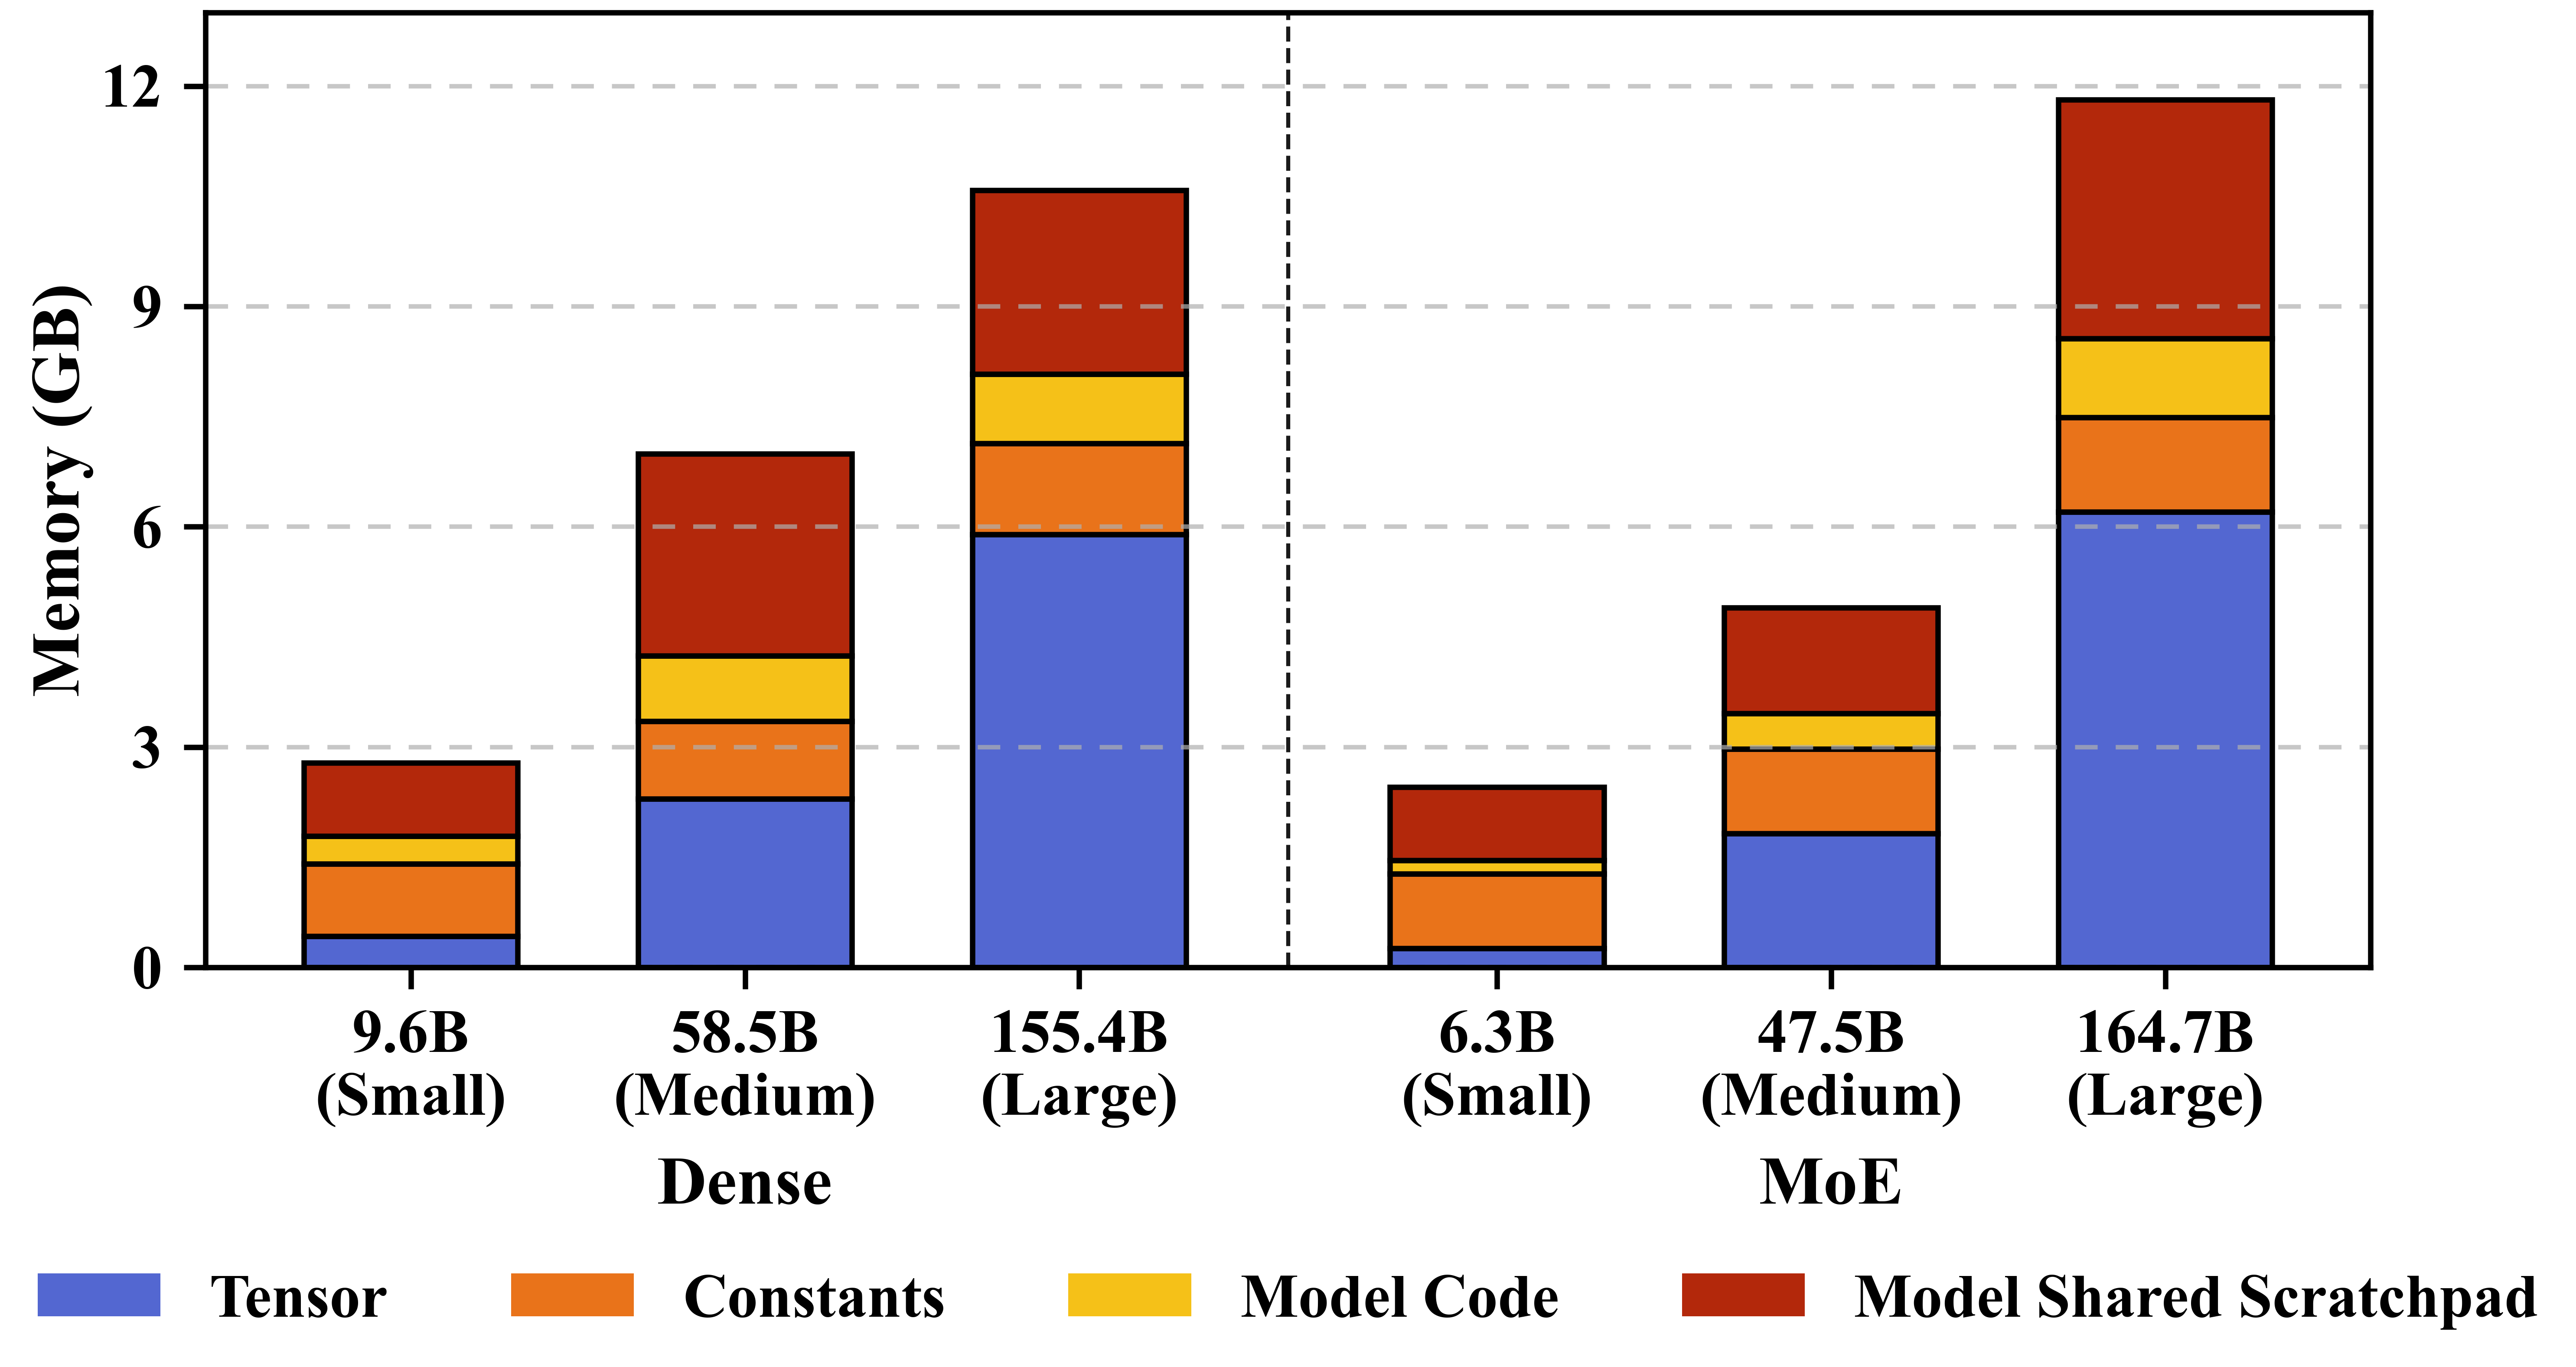

In [90]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 34,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 3,
        "xtick.major.width": 3,
        "ytick.major.width": 3,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

# ---- Reordered Data: Dense first, then Classic MoE ----
# Added '\n' to labels so they fit nicely without rotation
labels = [
    "9.6B\n(Small)",
    "58.5B\n(Medium)",
    "155.4B\n(Large)",
    "6.3B\n(Small)",
    "47.5B\n(Medium)",
    "164.7B\n(Large)",
]

parts = np.array(
    [
        # Tensor
        [0.4249, 2.2970, 5.8973, 0.2608, 1.8202, 6.2037],
        # Constants
        [0.9824, 1.0551, 1.2383, 1.0158, 1.1528, 1.2825],
        # Model Code
        [0.3804, 0.8898, 0.9453, 0.1801, 0.4860, 1.0771],
        # Model Shared Scratchpad
        [1.0000, 2.7501, 2.5000, 1.0000, 1.4377, 3.2504],
    ]
)

# ---- Layout Setup ----
# plt.rcParams.update({"font.size": 14})
x = np.arange(6, dtype=float)
gap = 0.25  # Gap between the two groups
x[3:] += gap

fig, ax = plt.subplots(figsize=(21, 12), dpi=300)

stacks = ["Tensor", "Constants", "Model Code", "Model Shared Scratchpad"]
colors = [
    # "#05c7b3",
    # "#ed7661",
    # "#009ddb",
    # "#ffaf1a",
    
    # "#023c66",
    # "#2996d4",
    # "#b3280b",
    # "#f5c118",

    *[
        "#5367d1",
        "#e9731a",
        "#f5c118",
        "#b3280b",
    ]
    # [::-1]
]
bottom = np.zeros(6)
bar_width = 0.64  # Reduced width to create more spacing between individual bars

# ---- Plotting Bars ----
for i in range(parts.shape[0]):
    ax.bar(
        x,
        parts[i],
        bottom=bottom,
        width=bar_width,
        label=stacks[i],
        color=colors[i],
        edgecolor="black",
        linewidth=3,
    )
    bottom += parts[i]

# ---- Formatting Axes ----
ax.set_xticks(x)
# rotation=0 keeps bars flat; multiline labels prevent overlap
ax.set_xticklabels(
    labels,
    fontsize=34,
    rotation=0,
    fontweight="bold",
)
ax.set_ylabel("Memory (GB)", fontsize=38, fontweight="bold")
ax.set_yticks([0, 3, 6, 9, 12])
ax.set_yticklabels([0, 3, 6, 9, 12], fontsize=34, fontweight="bold")
ax.tick_params(axis="y", length=12, pad=12)
ax.tick_params(axis="x", length=12, pad=12)
ax.set_ylim(0, 13)

# Group labels under the axis
group1_center = np.mean(x[:3])
group2_center = np.mean(x[3:])

# Lowered the 'y' position slightly (-0.15 -> -0.22) to account for double-line ticks
ax.text(
    group1_center,
    -0.2,
    "Dense",
    ha="center",
    va="top",
    fontsize=38,
    fontweight="bold",
    transform=ax.get_xaxis_transform(),
)
ax.text(
    group2_center,
    -0.2,
    "MoE",
    ha="center",
    va="top",
    fontsize=38,
    fontweight="bold",
    transform=ax.get_xaxis_transform(),
)

# Vertical separator
separator_x = (x[2] + x[3]) / 2
ax.axvline(
    separator_x,
    linestyle="--",
    color="black",
    linewidth=2.25,
    alpha=0.9,
)


# Legend
leg = ax.legend(
    ncols=4,
    bbox_to_anchor=(0.5, -0.35),
    loc="center",
    frameon=False,
    prop={"weight": "bold", "size": 34},
)
for h in leg.legend_handles:
    try:
        h.set_edgecolor("none")
        h.set_linewidth(0)
    except Exception:
        pass

ax.grid(
    axis="y",
    linestyle=(0, (5, 4)),
    linewidth=2.5,
    alpha=0.7,
    zorder=0,
)

# Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig(
    "CharacterizationMemoryBreakdown.pdf",
    # format="svg",
    bbox_inches="tight",
    # transparent=True,
    dpi=300,
)

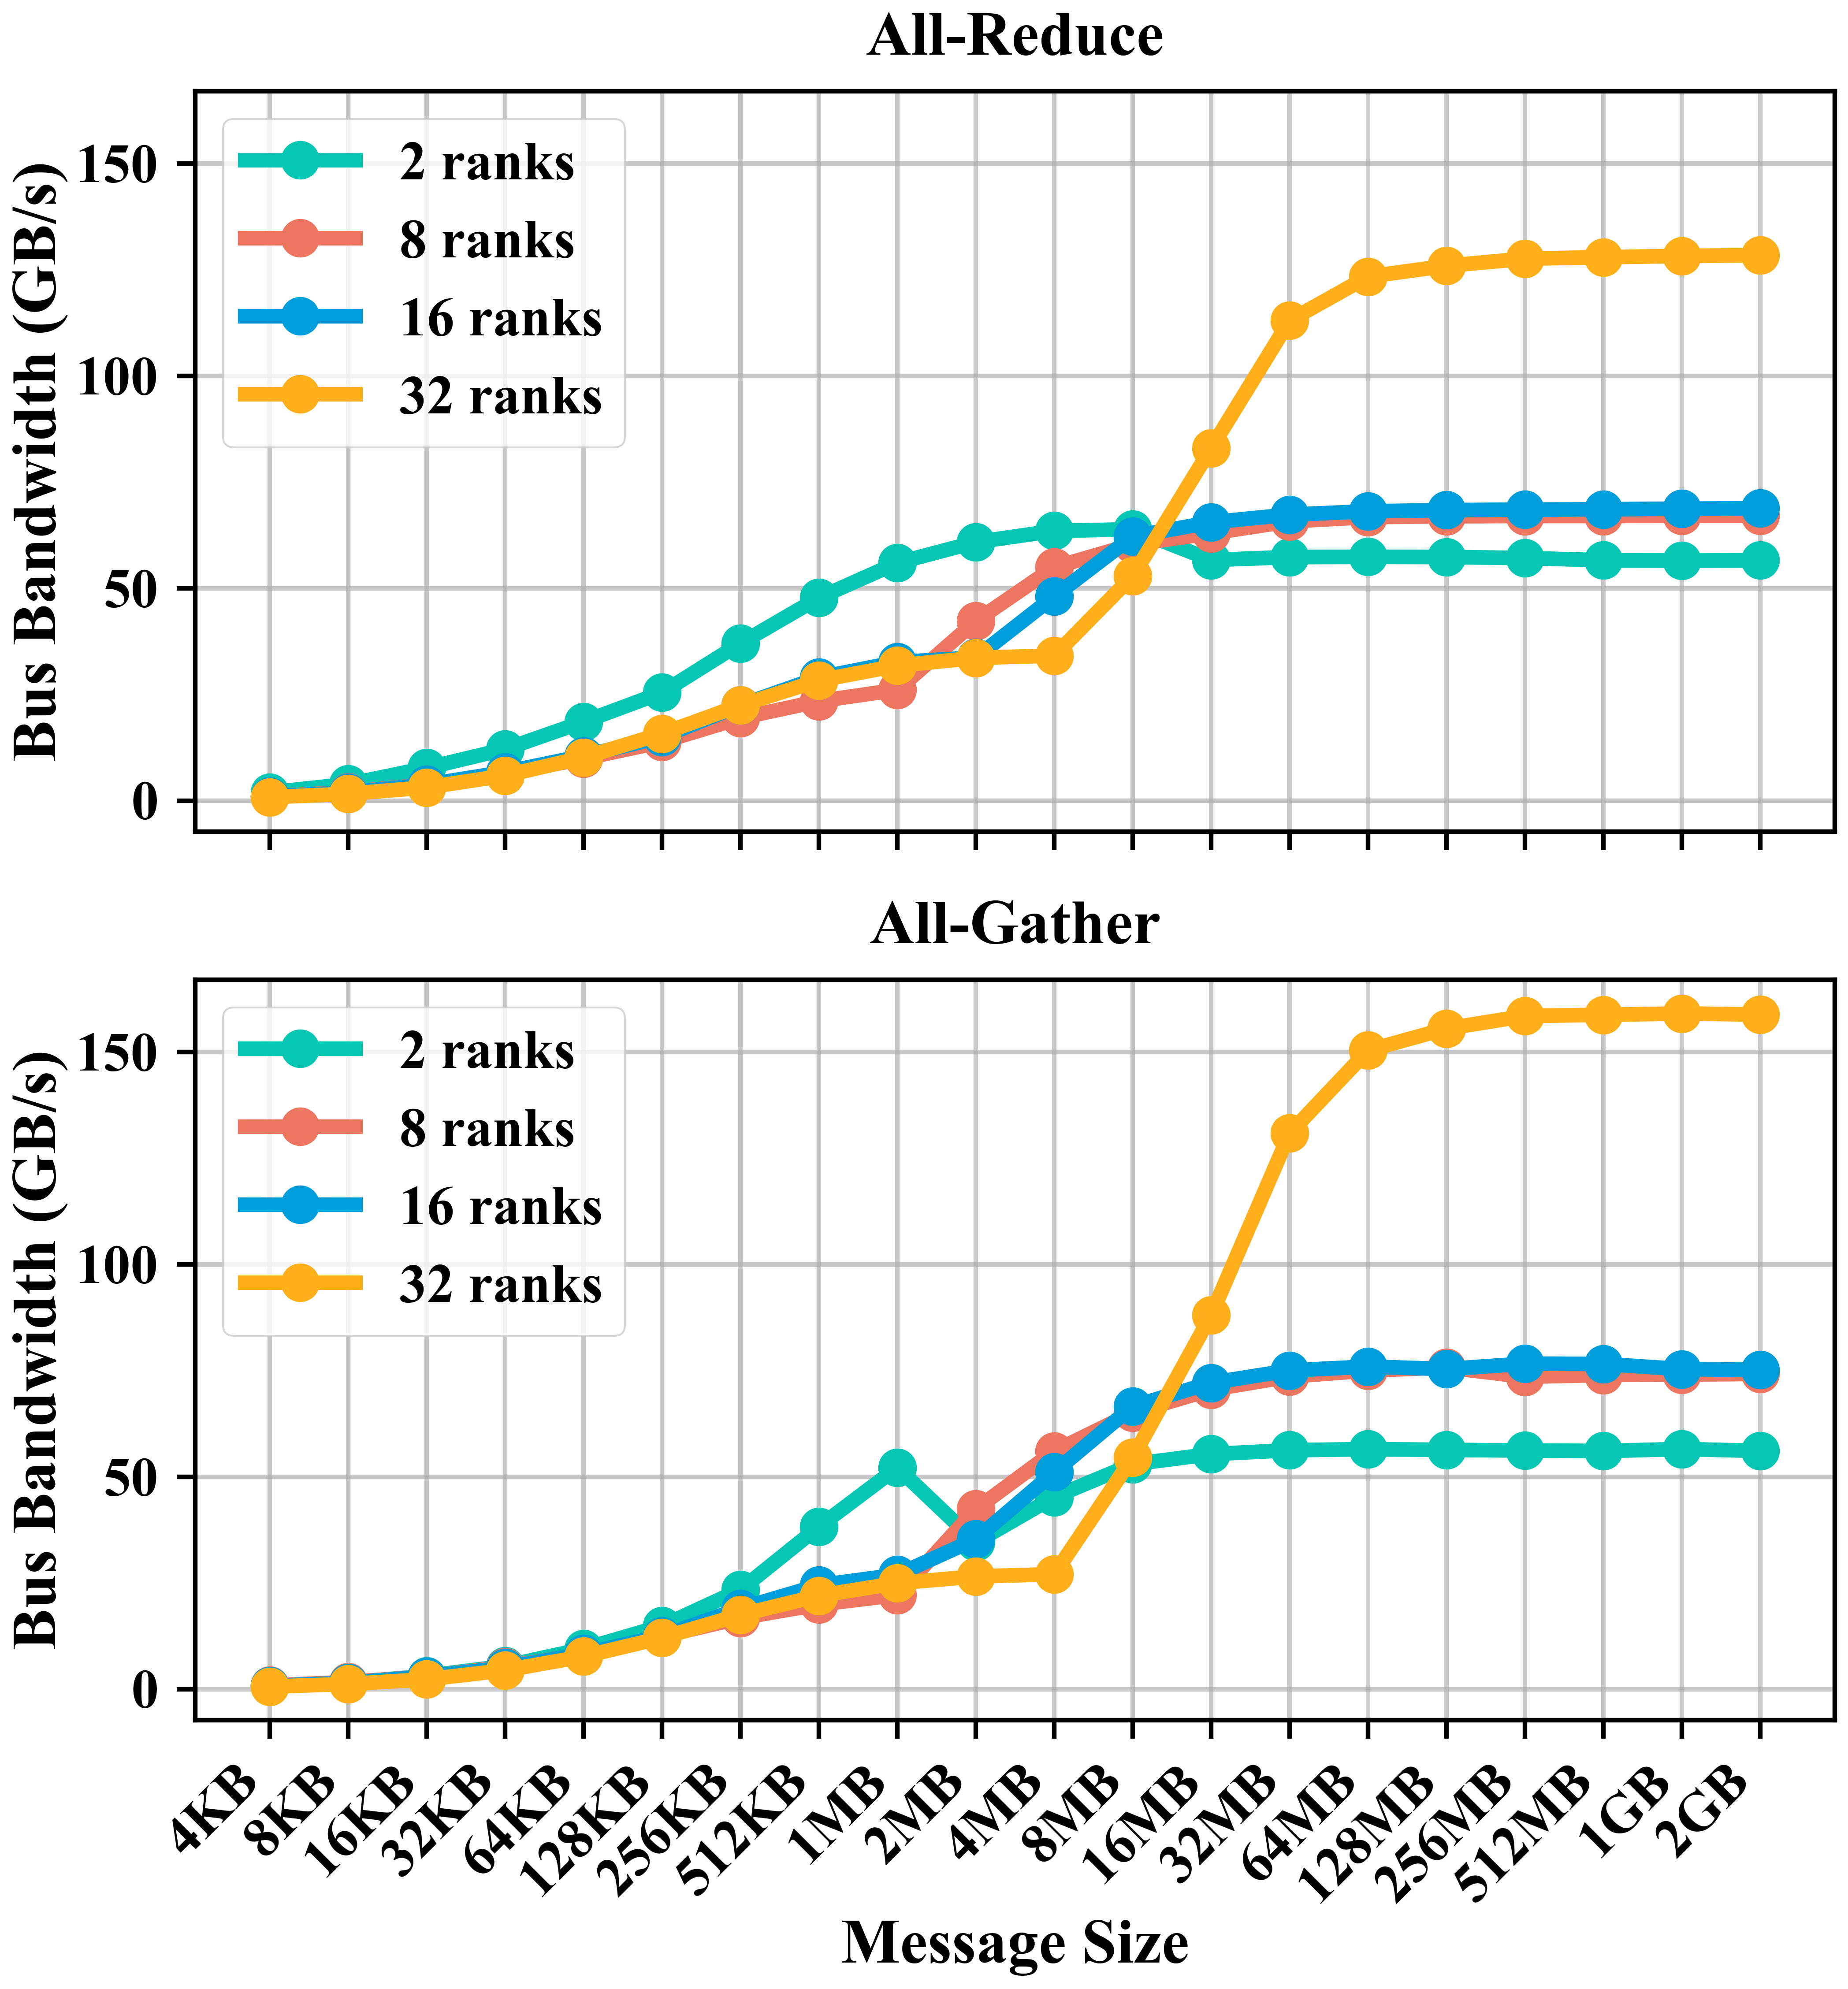

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)


K = 1024
M = 1024**2
G = 1024**3

# -----------------------------
# Put BOTH datasets in variables
# -----------------------------
data_a = [
    # 2 ranks
    # {"num_nodes": 2, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.49},
    # {"num_nodes": 2, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.98},
    {"num_nodes": 2, "data_size_bytes": 4 * K, "bus_bw_gbps": 1.95},
    {"num_nodes": 2, "data_size_bytes": 8 * K, "bus_bw_gbps": 3.90},
    {"num_nodes": 2, "data_size_bytes": 16 * K, "bus_bw_gbps": 7.71},
    {"num_nodes": 2, "data_size_bytes": 32 * K, "bus_bw_gbps": 12.14},
    {"num_nodes": 2, "data_size_bytes": 64 * K, "bus_bw_gbps": 18.59},
    {"num_nodes": 2, "data_size_bytes": 128 * K, "bus_bw_gbps": 25.45},
    {"num_nodes": 2, "data_size_bytes": 256 * K, "bus_bw_gbps": 37.05},
    {"num_nodes": 2, "data_size_bytes": 512 * K, "bus_bw_gbps": 47.77},
    {"num_nodes": 2, "data_size_bytes": 1 * M, "bus_bw_gbps": 56.00},
    {"num_nodes": 2, "data_size_bytes": 2 * M, "bus_bw_gbps": 60.88},
    {"num_nodes": 2, "data_size_bytes": 4 * M, "bus_bw_gbps": 63.53},
    {"num_nodes": 2, "data_size_bytes": 8 * M, "bus_bw_gbps": 63.89},
    {"num_nodes": 2, "data_size_bytes": 16 * M, "bus_bw_gbps": 56.66},
    {"num_nodes": 2, "data_size_bytes": 32 * M, "bus_bw_gbps": 57.36},
    {"num_nodes": 2, "data_size_bytes": 64 * M, "bus_bw_gbps": 57.41},
    {"num_nodes": 2, "data_size_bytes": 128 * M, "bus_bw_gbps": 57.37},
    {"num_nodes": 2, "data_size_bytes": 256 * M, "bus_bw_gbps": 57.13},
    {"num_nodes": 2, "data_size_bytes": 512 * M, "bus_bw_gbps": 56.61},
    {"num_nodes": 2, "data_size_bytes": 1 * G, "bus_bw_gbps": 56.52},
    {"num_nodes": 2, "data_size_bytes": 2 * G, "bus_bw_gbps": 56.59},
    # 8 ranks
    # {"num_nodes": 8, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.29},
    # {"num_nodes": 8, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.56},
    {"num_nodes": 8, "data_size_bytes": 4 * K, "bus_bw_gbps": 1.05},
    {"num_nodes": 8, "data_size_bytes": 8 * K, "bus_bw_gbps": 2.02},
    {"num_nodes": 8, "data_size_bytes": 16 * K, "bus_bw_gbps": 3.82},
    {"num_nodes": 8, "data_size_bytes": 32 * K, "bus_bw_gbps": 6.38},
    {"num_nodes": 8, "data_size_bytes": 64 * K, "bus_bw_gbps": 9.91},
    {"num_nodes": 8, "data_size_bytes": 128 * K, "bus_bw_gbps": 13.85},
    {"num_nodes": 8, "data_size_bytes": 256 * K, "bus_bw_gbps": 19.46},
    {"num_nodes": 8, "data_size_bytes": 512 * K, "bus_bw_gbps": 23.45},
    {"num_nodes": 8, "data_size_bytes": 1 * M, "bus_bw_gbps": 26.11},
    {"num_nodes": 8, "data_size_bytes": 2 * M, "bus_bw_gbps": 42.30},
    {"num_nodes": 8, "data_size_bytes": 4 * M, "bus_bw_gbps": 54.97},
    {"num_nodes": 8, "data_size_bytes": 8 * M, "bus_bw_gbps": 60.33},
    {"num_nodes": 8, "data_size_bytes": 16 * M, "bus_bw_gbps": 62.96},
    {"num_nodes": 8, "data_size_bytes": 32 * M, "bus_bw_gbps": 65.78},
    {"num_nodes": 8, "data_size_bytes": 64 * M, "bus_bw_gbps": 66.76},
    {"num_nodes": 8, "data_size_bytes": 128 * M, "bus_bw_gbps": 66.97},
    {"num_nodes": 8, "data_size_bytes": 256 * M, "bus_bw_gbps": 67.04},
    {"num_nodes": 8, "data_size_bytes": 512 * M, "bus_bw_gbps": 67.04},
    {"num_nodes": 8, "data_size_bytes": 1 * G, "bus_bw_gbps": 67.06},
    {"num_nodes": 8, "data_size_bytes": 2 * G, "bus_bw_gbps": 67.07},
    # 16 ranks
    # {"num_nodes": 16, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.27},
    # {"num_nodes": 16, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.53},
    {"num_nodes": 16, "data_size_bytes": 4 * K, "bus_bw_gbps": 1.01},
    {"num_nodes": 16, "data_size_bytes": 8 * K, "bus_bw_gbps": 1.91},
    {"num_nodes": 16, "data_size_bytes": 16 * K, "bus_bw_gbps": 3.78},
    {"num_nodes": 16, "data_size_bytes": 32 * K, "bus_bw_gbps": 6.74},
    {"num_nodes": 16, "data_size_bytes": 64 * K, "bus_bw_gbps": 10.55},
    {"num_nodes": 16, "data_size_bytes": 128 * K, "bus_bw_gbps": 15.02},
    {"num_nodes": 16, "data_size_bytes": 256 * K, "bus_bw_gbps": 22.49},
    {"num_nodes": 16, "data_size_bytes": 512 * K, "bus_bw_gbps": 29.00},
    {"num_nodes": 16, "data_size_bytes": 1 * M, "bus_bw_gbps": 32.64},
    {"num_nodes": 16, "data_size_bytes": 2 * M, "bus_bw_gbps": 33.69},
    {"num_nodes": 16, "data_size_bytes": 4 * M, "bus_bw_gbps": 48.13},
    {"num_nodes": 16, "data_size_bytes": 8 * M, "bus_bw_gbps": 62.21},
    {"num_nodes": 16, "data_size_bytes": 16 * M, "bus_bw_gbps": 65.55},
    {"num_nodes": 16, "data_size_bytes": 32 * M, "bus_bw_gbps": 67.35},
    {"num_nodes": 16, "data_size_bytes": 64 * M, "bus_bw_gbps": 68.13},
    {"num_nodes": 16, "data_size_bytes": 128 * M, "bus_bw_gbps": 68.41},
    {"num_nodes": 16, "data_size_bytes": 256 * M, "bus_bw_gbps": 68.52},
    {"num_nodes": 16, "data_size_bytes": 512 * M, "bus_bw_gbps": 68.61},
    {"num_nodes": 16, "data_size_bytes": 1 * G, "bus_bw_gbps": 68.75},
    {"num_nodes": 16, "data_size_bytes": 2 * G, "bus_bw_gbps": 68.84},
    # 32 ranks
    # {"num_nodes": 32, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.22},
    # {"num_nodes": 32, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.43},
    {"num_nodes": 32, "data_size_bytes": 4 * K, "bus_bw_gbps": 0.83},
    {"num_nodes": 32, "data_size_bytes": 8 * K, "bus_bw_gbps": 1.63},
    {"num_nodes": 32, "data_size_bytes": 16 * K, "bus_bw_gbps": 3.13},
    {"num_nodes": 32, "data_size_bytes": 32 * K, "bus_bw_gbps": 5.91},
    {"num_nodes": 32, "data_size_bytes": 64 * K, "bus_bw_gbps": 10.19},
    {"num_nodes": 32, "data_size_bytes": 128 * K, "bus_bw_gbps": 15.79},
    {"num_nodes": 32, "data_size_bytes": 256 * K, "bus_bw_gbps": 22.48},
    {"num_nodes": 32, "data_size_bytes": 512 * K, "bus_bw_gbps": 28.30},
    {"num_nodes": 32, "data_size_bytes": 1 * M, "bus_bw_gbps": 31.80},
    {"num_nodes": 32, "data_size_bytes": 2 * M, "bus_bw_gbps": 33.64},
    {"num_nodes": 32, "data_size_bytes": 4 * M, "bus_bw_gbps": 34.14},
    {"num_nodes": 32, "data_size_bytes": 8 * M, "bus_bw_gbps": 52.92},
    {"num_nodes": 32, "data_size_bytes": 16 * M, "bus_bw_gbps": 83.02},
    {"num_nodes": 32, "data_size_bytes": 32 * M, "bus_bw_gbps": 113.05},
    {"num_nodes": 32, "data_size_bytes": 64 * M, "bus_bw_gbps": 123.39},
    {"num_nodes": 32, "data_size_bytes": 128 * M, "bus_bw_gbps": 125.93},
    {"num_nodes": 32, "data_size_bytes": 256 * M, "bus_bw_gbps": 127.62},
    {"num_nodes": 32, "data_size_bytes": 512 * M, "bus_bw_gbps": 127.94},
    {"num_nodes": 32, "data_size_bytes": 1 * G, "bus_bw_gbps": 128.27},
    {"num_nodes": 32, "data_size_bytes": 2 * G, "bus_bw_gbps": 128.41},
]

data_b = [
    # 2 ranks
    # {"num_nodes": 2, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.20},
    # {"num_nodes": 2, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.41},
    {"num_nodes": 2, "data_size_bytes": 4 * K, "bus_bw_gbps": 0.79},
    {"num_nodes": 2, "data_size_bytes": 8 * K, "bus_bw_gbps": 1.56},
    {"num_nodes": 2, "data_size_bytes": 16 * K, "bus_bw_gbps": 3.12},
    {"num_nodes": 2, "data_size_bytes": 32 * K, "bus_bw_gbps": 5.46},
    {"num_nodes": 2, "data_size_bytes": 64 * K, "bus_bw_gbps": 9.50},
    {"num_nodes": 2, "data_size_bytes": 128 * K, "bus_bw_gbps": 14.89},
    {"num_nodes": 2, "data_size_bytes": 256 * K, "bus_bw_gbps": 23.41},
    {"num_nodes": 2, "data_size_bytes": 512 * K, "bus_bw_gbps": 38.27},
    {"num_nodes": 2, "data_size_bytes": 1 * M, "bus_bw_gbps": 52.17},
    {"num_nodes": 2, "data_size_bytes": 2 * M, "bus_bw_gbps": 34.61},
    {"num_nodes": 2, "data_size_bytes": 4 * M, "bus_bw_gbps": 45.25},
    {"num_nodes": 2, "data_size_bytes": 8 * M, "bus_bw_gbps": 52.99},
    {"num_nodes": 2, "data_size_bytes": 16 * M, "bus_bw_gbps": 55.35},
    {"num_nodes": 2, "data_size_bytes": 32 * M, "bus_bw_gbps": 56.27},
    {"num_nodes": 2, "data_size_bytes": 64 * M, "bus_bw_gbps": 56.51},
    {"num_nodes": 2, "data_size_bytes": 128 * M, "bus_bw_gbps": 56.34},
    {"num_nodes": 2, "data_size_bytes": 256 * M, "bus_bw_gbps": 56.20},
    {"num_nodes": 2, "data_size_bytes": 512 * M, "bus_bw_gbps": 56.08},
    {"num_nodes": 2, "data_size_bytes": 1 * G, "bus_bw_gbps": 56.54},
    {"num_nodes": 2, "data_size_bytes": 2 * G, "bus_bw_gbps": 56.10},
    # 8 ranks
    # {"num_nodes": 8, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.22},
    # {"num_nodes": 8, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.44},
    {"num_nodes": 8, "data_size_bytes": 4 * K, "bus_bw_gbps": 0.87},
    {"num_nodes": 8, "data_size_bytes": 8 * K, "bus_bw_gbps": 1.70},
    {"num_nodes": 8, "data_size_bytes": 16 * K, "bus_bw_gbps": 2.94},
    {"num_nodes": 8, "data_size_bytes": 32 * K, "bus_bw_gbps": 5.27},
    {"num_nodes": 8, "data_size_bytes": 64 * K, "bus_bw_gbps": 8.25},
    {"num_nodes": 8, "data_size_bytes": 128 * K, "bus_bw_gbps": 12.45},
    {"num_nodes": 8, "data_size_bytes": 256 * K, "bus_bw_gbps": 16.77},
    {"num_nodes": 8, "data_size_bytes": 512 * K, "bus_bw_gbps": 19.95},
    {"num_nodes": 8, "data_size_bytes": 1 * M, "bus_bw_gbps": 22.19},
    {"num_nodes": 8, "data_size_bytes": 2 * M, "bus_bw_gbps": 42.39},
    {"num_nodes": 8, "data_size_bytes": 4 * M, "bus_bw_gbps": 56.04},
    {"num_nodes": 8, "data_size_bytes": 8 * M, "bus_bw_gbps": 65.09},
    {"num_nodes": 8, "data_size_bytes": 16 * M, "bus_bw_gbps": 70.54},
    {"num_nodes": 8, "data_size_bytes": 32 * M, "bus_bw_gbps": 73.62},
    {"num_nodes": 8, "data_size_bytes": 64 * M, "bus_bw_gbps": 75.03},
    {"num_nodes": 8, "data_size_bytes": 128 * M, "bus_bw_gbps": 75.76},
    {"num_nodes": 8, "data_size_bytes": 256 * M, "bus_bw_gbps": 73.55},
    {"num_nodes": 8, "data_size_bytes": 512 * M, "bus_bw_gbps": 73.98},
    {"num_nodes": 8, "data_size_bytes": 1 * G, "bus_bw_gbps": 74.10},
    {"num_nodes": 8, "data_size_bytes": 2 * G, "bus_bw_gbps": 74.23},
    # 16 ranks
    # {"num_nodes": 16, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.19},
    # {"num_nodes": 16, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.38},
    {"num_nodes": 16, "data_size_bytes": 4 * K, "bus_bw_gbps": 0.76},
    {"num_nodes": 16, "data_size_bytes": 8 * K, "bus_bw_gbps": 1.51},
    {"num_nodes": 16, "data_size_bytes": 16 * K, "bus_bw_gbps": 2.96},
    {"num_nodes": 16, "data_size_bytes": 32 * K, "bus_bw_gbps": 5.06},
    {"num_nodes": 16, "data_size_bytes": 64 * K, "bus_bw_gbps": 8.36},
    {"num_nodes": 16, "data_size_bytes": 128 * K, "bus_bw_gbps": 12.53},
    {"num_nodes": 16, "data_size_bytes": 256 * K, "bus_bw_gbps": 19.01},
    {"num_nodes": 16, "data_size_bytes": 512 * K, "bus_bw_gbps": 24.47},
    {"num_nodes": 16, "data_size_bytes": 1 * M, "bus_bw_gbps": 26.94},
    {"num_nodes": 16, "data_size_bytes": 2 * M, "bus_bw_gbps": 35.33},
    {"num_nodes": 16, "data_size_bytes": 4 * M, "bus_bw_gbps": 51.10},
    {"num_nodes": 16, "data_size_bytes": 8 * M, "bus_bw_gbps": 66.61},
    {"num_nodes": 16, "data_size_bytes": 16 * M, "bus_bw_gbps": 72.14},
    {"num_nodes": 16, "data_size_bytes": 32 * M, "bus_bw_gbps": 75.04},
    {"num_nodes": 16, "data_size_bytes": 64 * M, "bus_bw_gbps": 75.95},
    {"num_nodes": 16, "data_size_bytes": 128 * M, "bus_bw_gbps": 75.37},
    {"num_nodes": 16, "data_size_bytes": 256 * M, "bus_bw_gbps": 76.64},
    {"num_nodes": 16, "data_size_bytes": 512 * M, "bus_bw_gbps": 76.58},
    {"num_nodes": 16, "data_size_bytes": 1 * G, "bus_bw_gbps": 75.35},
    {"num_nodes": 16, "data_size_bytes": 2 * G, "bus_bw_gbps": 75.20},
    # 32 ranks
    # {"num_nodes": 32, "data_size_bytes": 1 * K,         "bus_bw_gbps": 0.16},
    # {"num_nodes": 32, "data_size_bytes": 2 * K,         "bus_bw_gbps": 0.32},
    {"num_nodes": 32, "data_size_bytes": 4 * K, "bus_bw_gbps": 0.62},
    {"num_nodes": 32, "data_size_bytes": 8 * K, "bus_bw_gbps": 1.22},
    {"num_nodes": 32, "data_size_bytes": 16 * K, "bus_bw_gbps": 2.33},
    {"num_nodes": 32, "data_size_bytes": 32 * K, "bus_bw_gbps": 4.45},
    {"num_nodes": 32, "data_size_bytes": 64 * K, "bus_bw_gbps": 7.72},
    {"num_nodes": 32, "data_size_bytes": 128 * K, "bus_bw_gbps": 12.11},
    {"num_nodes": 32, "data_size_bytes": 256 * K, "bus_bw_gbps": 17.53},
    {"num_nodes": 32, "data_size_bytes": 512 * K, "bus_bw_gbps": 22.02},
    {"num_nodes": 32, "data_size_bytes": 1 * M, "bus_bw_gbps": 24.98},
    {"num_nodes": 32, "data_size_bytes": 2 * M, "bus_bw_gbps": 26.55},
    {"num_nodes": 32, "data_size_bytes": 4 * M, "bus_bw_gbps": 27.08},
    {"num_nodes": 32, "data_size_bytes": 8 * M, "bus_bw_gbps": 54.56},
    {"num_nodes": 32, "data_size_bytes": 16 * M, "bus_bw_gbps": 88.08},
    {"num_nodes": 32, "data_size_bytes": 32 * M, "bus_bw_gbps": 130.89},
    {"num_nodes": 32, "data_size_bytes": 64 * M, "bus_bw_gbps": 150.40},
    {"num_nodes": 32, "data_size_bytes": 128 * M, "bus_bw_gbps": 155.53},
    {"num_nodes": 32, "data_size_bytes": 256 * M, "bus_bw_gbps": 158.50},
    {"num_nodes": 32, "data_size_bytes": 512 * M, "bus_bw_gbps": 158.77},
    {"num_nodes": 32, "data_size_bytes": 1 * G, "bus_bw_gbps": 159.09},
    {"num_nodes": 32, "data_size_bytes": 2 * G, "bus_bw_gbps": 158.83},
]

df_a = pd.DataFrame(data_a).sort_values("data_size_bytes")
df_b = pd.DataFrame(data_b).sort_values("data_size_bytes")


def human_readable_size(bytes_val):
    KB = 1024
    MB = 1024**2
    GB = 1024**3
    if bytes_val < MB:
        return f"{bytes_val / KB:.0f}KB"
    elif bytes_val < GB:
        return f"{bytes_val / MB:.0f}MB"
    else:
        return f"{bytes_val / GB:.0f}GB"


# -----------------------------
# Common ticks (cover both dfs)
# -----------------------------
xticks = [
    4 * K,
    8 * K,
    16 * K,
    32 * K,
    64 * K,
    128 * K,
    256 * K,
    512 * K,
    1 * M,
    2 * M,
    4 * M,
    8 * M,
    16 * M,
    32 * M,
    64 * M,
    128 * M,
    256 * M,
    512 * M,
    1 * G,
    2 * G,
]

global_min = min(df_a["data_size_bytes"].min(), df_b["data_size_bytes"].min())
global_max = max(df_a["data_size_bytes"].max(), df_b["data_size_bytes"].max())
xticks = [x for x in xticks if global_min <= x <= global_max]


# -----------------------------
# Plot helper (so both panels match)
# -----------------------------
def plot_df(ax, df, title):
    # cmap = plt.get_cmap("Set2")
    cmap = [
        "#05c7b3",
        "#ed7661",
        "#009ddb",
        "#ffaf1a",
    ]

    for i, (num_nodes, group) in enumerate(df.groupby("num_nodes")):
        group = group.sort_values("data_size_bytes")
        ax.plot(
            group["data_size_bytes"],
            group["bus_bw_gbps"],
            marker="o",
            linestyle="-",
            label=f"{num_nodes} rank{'s' if num_nodes > 1 else ''}",
            color=cmap[i % len(cmap)],
            linewidth=8,
            markersize=20,
        )

    ax.set_xscale("log", base=2)
    ax.set_title(title, fontsize=34, fontweight="bold", pad=20)
    # ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.grid(True, linestyle="-", linewidth=2.5, alpha=0.7)


# -----------------------------
# Stacked subplots, shared axes
# -----------------------------
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16, 16),  # two 3-inch-tall panels stacked
    sharex=True,
    sharey=True,
    dpi=300,
)

plot_df(ax1, df_a, "All-Reduce")
plot_df(ax2, df_b, "All-Gather")

# Labels (one y-label for both is cleaner)
ax2.set_xlabel("Message Size", fontsize=34, fontweight="bold")
ax1.set_ylabel("Bus Bandwidth (GB/s)", fontsize=34, fontweight="bold")
ax2.set_ylabel("Bus Bandwidth (GB/s)", fontsize=34, fontweight="bold")

# Same ticks/labels for both (show tick labels only on bottom panel)
ax2.set_xticks(xticks)
ax2.set_xticklabels(
    [human_readable_size(x) for x in xticks],
    rotation=45,
    ha="right",
    fontsize=30,
    fontweight="bold",
)

ax1.tick_params(axis="y", length=10, pad=10)
ax1.tick_params(axis="x", length=10, pad=10)
ax2.tick_params(axis="y", length=10, pad=10)
ax2.tick_params(axis="x", length=10, pad=10)

ax1.set_yticks([0, 50, 100, 150])
ax1.set_yticklabels([0, 50, 100, 150], fontsize=30, fontweight="bold")
ax2.set_yticks([0, 50, 100, 150])
ax2.set_yticklabels([0, 50, 100, 150], fontsize=30, fontweight="bold")

# ax1.set_ylim(0, 175)
# ax2.set_ylim(0, 175)

# # One legend for the whole figure (avoids duplicates)
# handles, labels = ax1.get_legend_handles_labels()
# fig.legend(
#     handles,
#     labels,
#     loc="upper center",
#     ncol=4,
#     frameon=False,
#     prop={"weight": "bold", "size": 30},
# )
ax1.legend(
    loc="upper left",
    prop={"weight": "bold", "size": 30},
)
ax2.legend(
    loc="upper left",
    prop={"weight": "bold", "size": 30},
)

# plt.tight_layout(rect=[0, 0, 1, 0.92])  # leave room for the figure legend
plt.show()
fig.savefig(
    "CharacterizationIntraNode.pdf",
    # format="svg",
    bbox_inches="tight",
    # transparent=True,
    dpi=300,
)

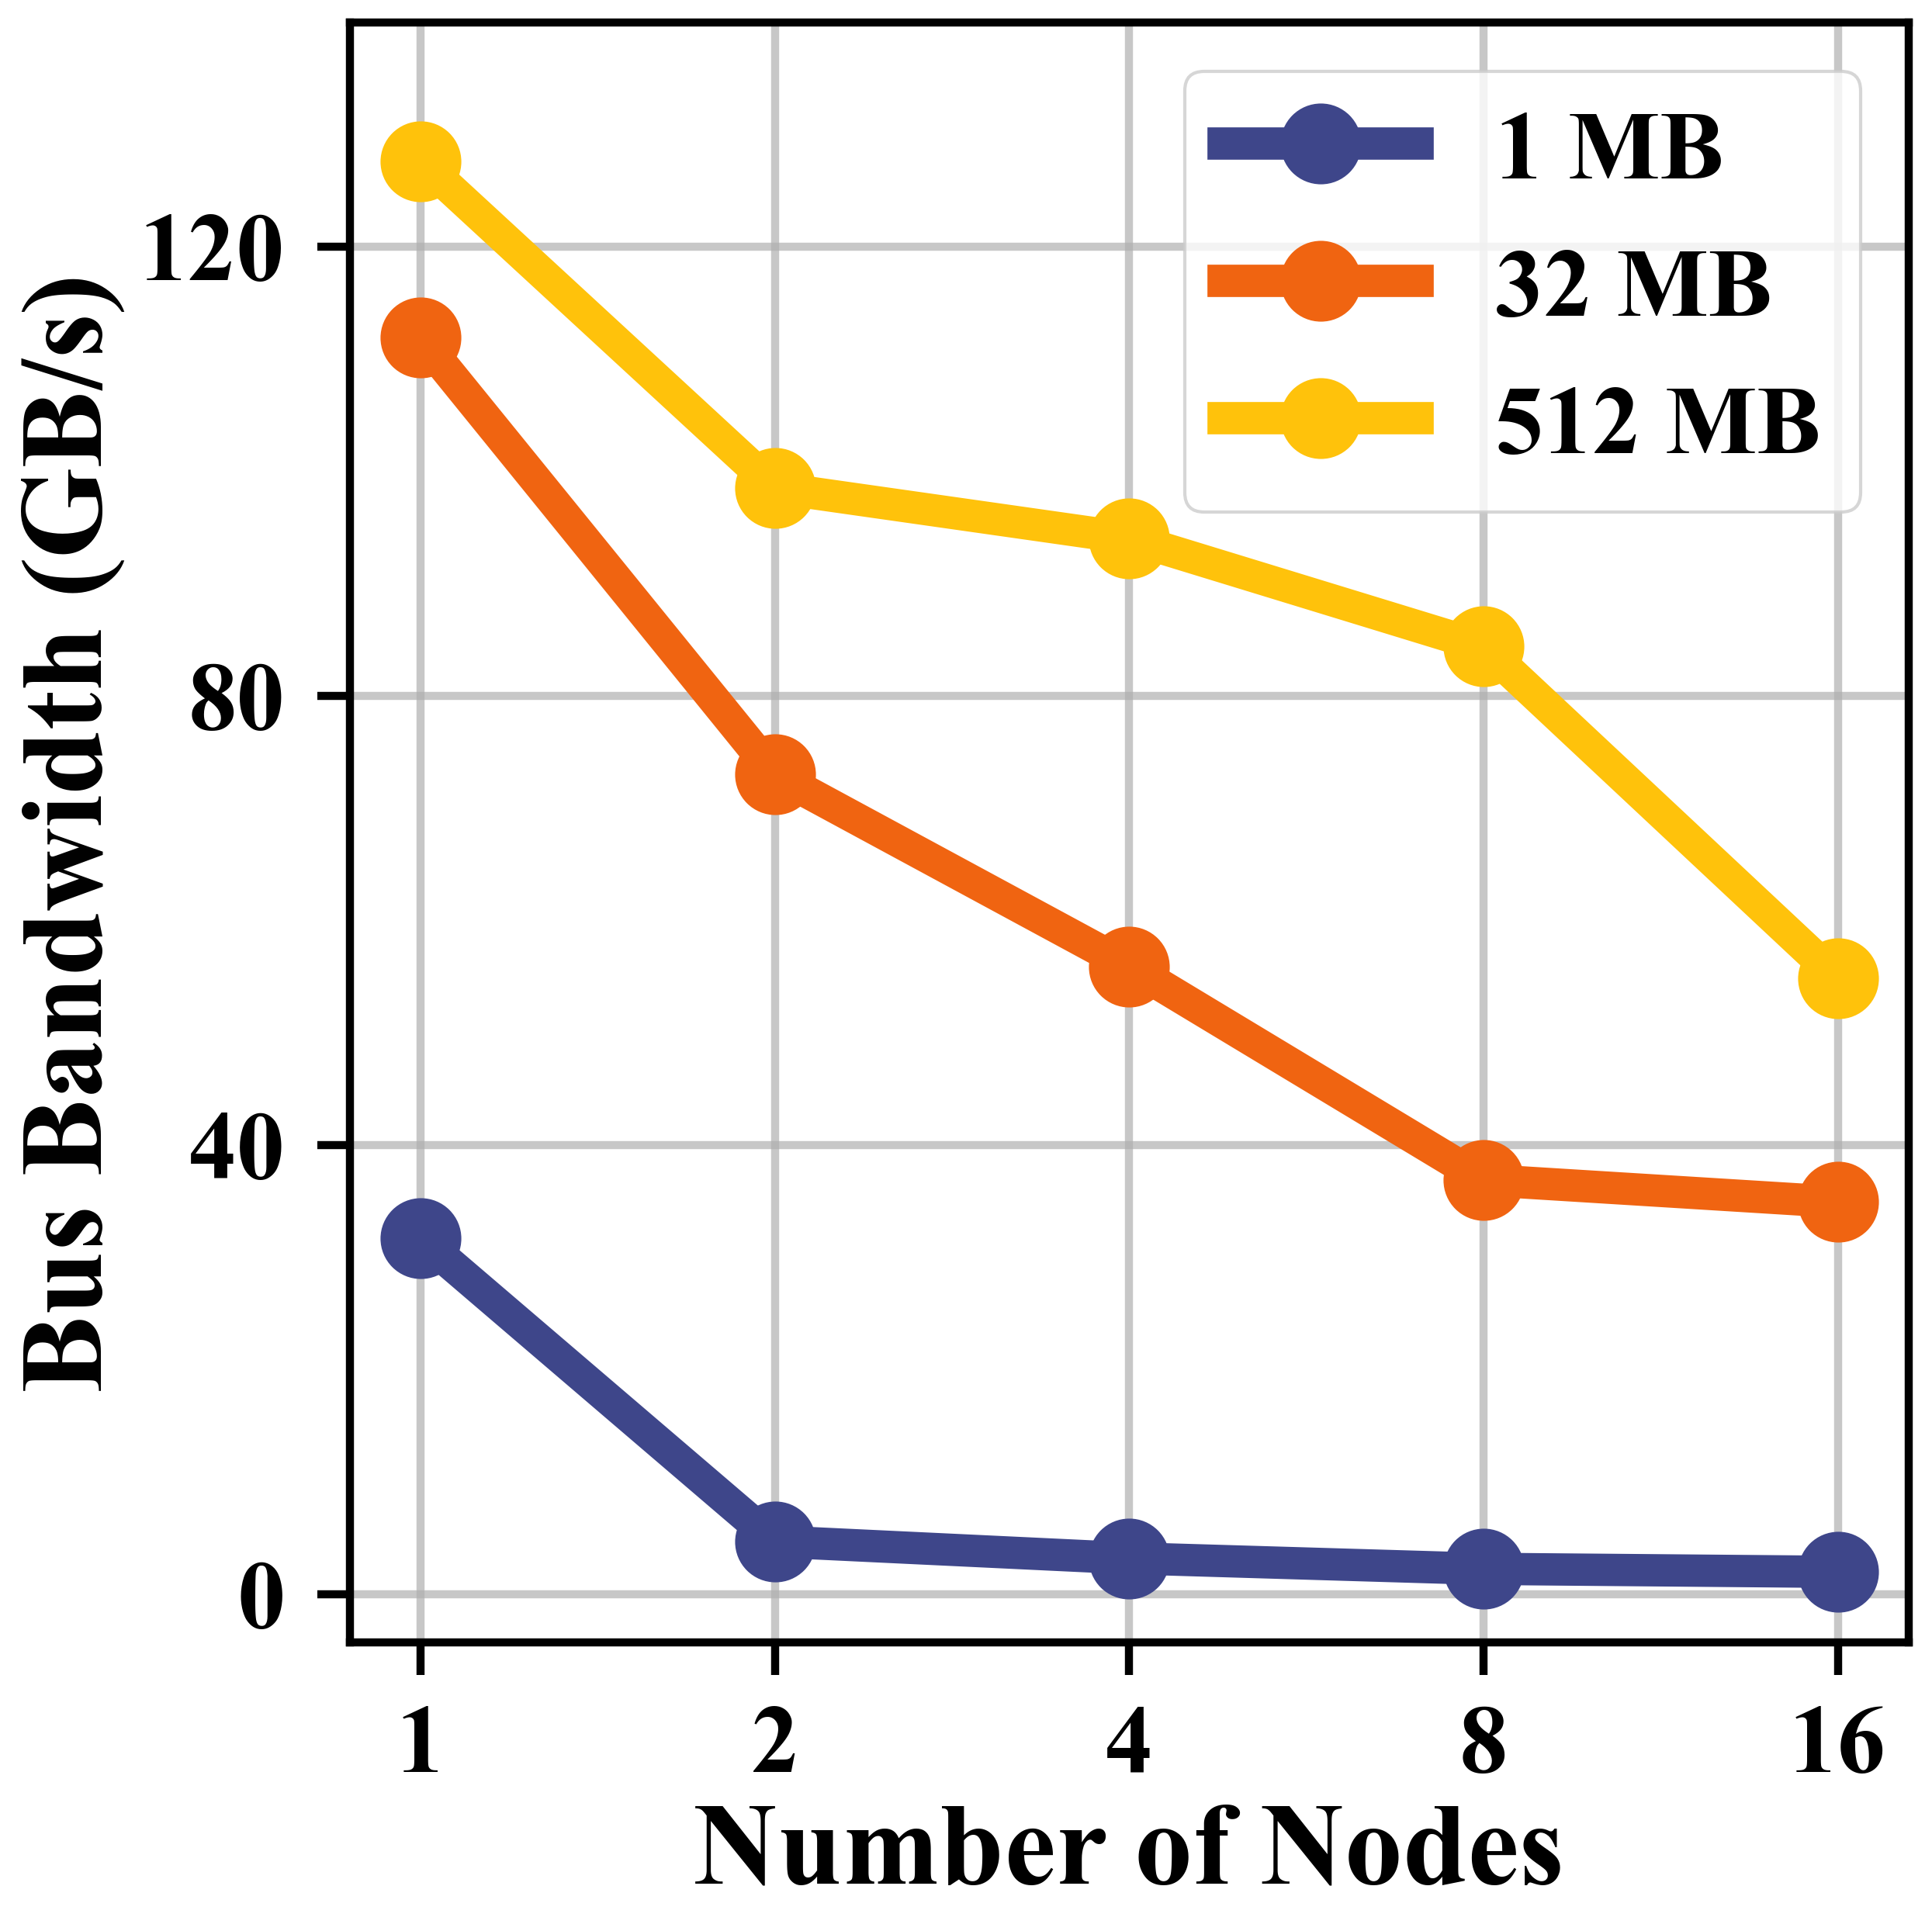

In [73]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict

# -----------------------------
# Input data
# -----------------------------
data_a = [
    {"num_nodes": 1, "data_size_bytes": 1 * 1024 * 1024, "bus_bw_gbps": 31.73},
    {"num_nodes": 2, "data_size_bytes": 1 * 1024 * 1024, "bus_bw_gbps": 4.73},
    {"num_nodes": 4, "data_size_bytes": 1 * 1024 * 1024, "bus_bw_gbps": 3.23},
    {"num_nodes": 8, "data_size_bytes": 1 * 1024 * 1024, "bus_bw_gbps": 2.29},
    {"num_nodes": 16, "data_size_bytes": 1 * 1024 * 1024, "bus_bw_gbps": 2.02},

    {"num_nodes": 1, "data_size_bytes": 32 * 1024 * 1024, "bus_bw_gbps": 111.92},
    {"num_nodes": 2, "data_size_bytes": 32 * 1024 * 1024, "bus_bw_gbps": 73.02},
    {"num_nodes": 4, "data_size_bytes": 32 * 1024 * 1024, "bus_bw_gbps": 55.95},
    {"num_nodes": 8, "data_size_bytes": 32 * 1024 * 1024, "bus_bw_gbps": 36.92},
    {"num_nodes": 16, "data_size_bytes": 32 * 1024 * 1024, "bus_bw_gbps": 34.97},

    {"num_nodes": 1, "data_size_bytes": 512 * 1024 * 1024, "bus_bw_gbps": 127.66},
    {"num_nodes": 2, "data_size_bytes": 512 * 1024 * 1024, "bus_bw_gbps": 98.57},
    {"num_nodes": 4, "data_size_bytes": 512 * 1024 * 1024, "bus_bw_gbps": 94.08},
    {"num_nodes": 8, "data_size_bytes": 512 * 1024 * 1024, "bus_bw_gbps": 84.42},
    {"num_nodes": 16, "data_size_bytes": 512 * 1024 * 1024, "bus_bw_gbps": 54.88},
]

# -----------------------------
# Styling (kept close to your script)
# -----------------------------
plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

# -----------------------------
# Helpers
# -----------------------------
def bytes_to_mib(x_bytes: int) -> float:
    return x_bytes / (1024 * 1024)

def fmt_size(bytes_val: int) -> str:
    mib = bytes_to_mib(bytes_val)
    # Nice labels for your specific sizes
    if abs(mib - 1) < 1e-9:
        return "1 MB"
    if abs(mib - 32) < 1e-9:
        return "32 MB"
    if abs(mib - 512) < 1e-9:
        return "512 MB"
    # fallback
    if mib >= 1024:
        return f"{mib/1024:.0f} GB"
    return f"{mib:.0f} MB"

def label_points(ax, xs, ys, fmt="{:.2f}", dy=12):
    for xi, yi in zip(xs, ys):
        ax.annotate(
            fmt.format(yi),
            (xi, yi),
            textcoords="offset points",
            xytext=(0, dy),
            ha="center",
            va="bottom",
            clip_on=False,
            fontsize=26,  # slightly smaller than axis font; adjust as desired
        )

# -----------------------------
# Group data by data_size_bytes
# -----------------------------
by_size = defaultdict(list)
for row in data_a:
    by_size[row["data_size_bytes"]].append(row)

sizes_sorted = sorted(by_size.keys())
x_all = sorted({row["num_nodes"] for row in data_a})

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 9), dpi=300)

# If you want deterministic marker choices per line:

cmap = [
    "#3e468a",
    "#f06411",
    "#ffc20b",
]
for i, sz in enumerate(sizes_sorted):
    rows = sorted(by_size[sz], key=lambda r: r["num_nodes"])
    x = [r["num_nodes"] for r in rows]
    y = [r["bus_bw_gbps"] for r in rows]

    ax.plot(
        x,
        y,
        label=fmt_size(sz),
        linewidth=10,
        marker="o",
        markersize=24,
        color=cmap[i % len(cmap)],
    )
    # Optional point labels (uncomment if you want them)
    # label_points(ax, x, y, fmt="{:.2f}", dy=12)

ax.set_xscale("log", base=2)
ax.set_xticks(x_all)
ax.set_xticklabels([str(v) for v in x_all], fontweight="bold")

# Optional: fixed y-ticks (comment out if you prefer auto ticks)
yticks = [0, 40, 80, 120]
ax.set_yticks(yticks)
ax.set_yticklabels([str(v) for v in yticks], fontweight="bold")
ax.set_ylim(None, 140)

ax.tick_params(axis="y", length=10, pad=10)
ax.tick_params(axis="x", length=10, pad=10)

ax.set_xlabel("Number of Nodes", fontsize=36, fontweight="bold")
ax.set_ylabel("Bus Bandwidth (GB/s)", fontsize=36, fontweight="bold")

ax.legend(loc="upper right", prop={"weight": "bold"})
ax.grid(True, linestyle="-", linewidth=2.5, alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(
    "CharacterizationInterNodeWeakScaling.pdf",
    bbox_inches="tight",
    dpi=300,
)

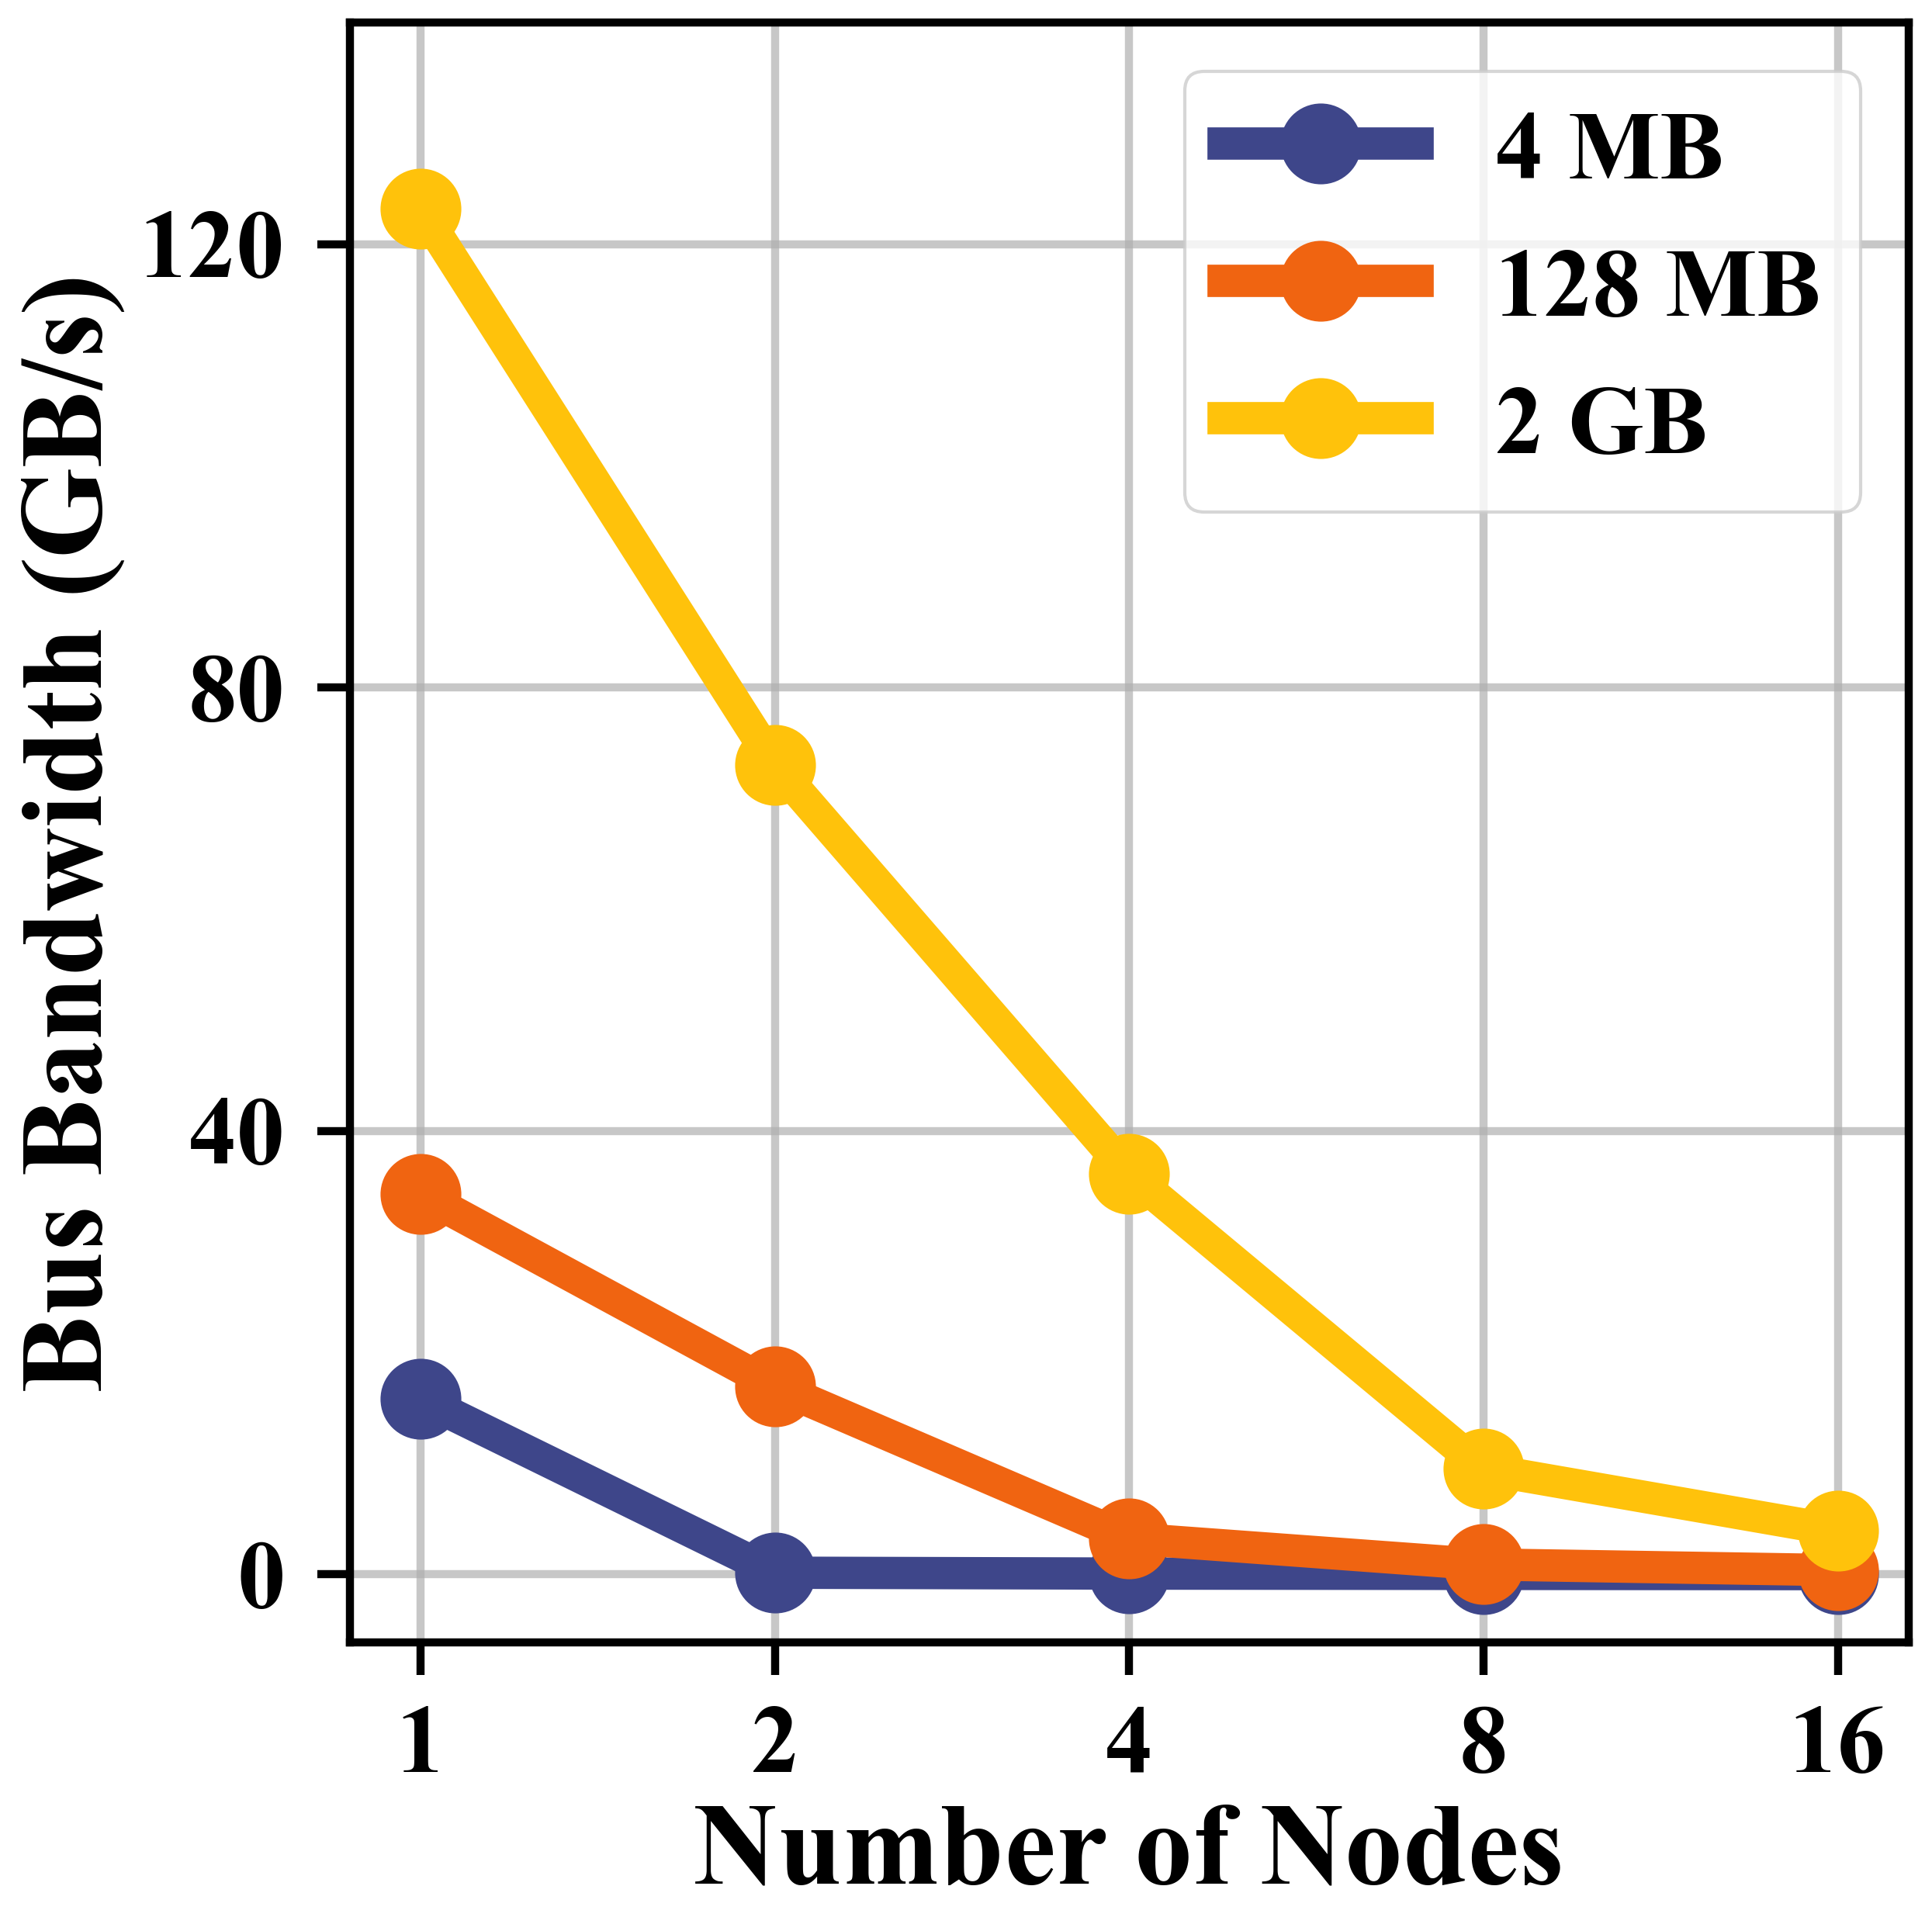

In [74]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict

# -----------------------------
# Input data
# -----------------------------
data_a = [
    # Example:
    {"num_nodes": 1, "data_size_bytes": 4 * 1024 * 1024, "bus_bw_gbps": 15.82}, # 128K
    {"num_nodes": 2, "data_size_bytes": 4 * 1024 * 1024, "bus_bw_gbps": 0.14}, # 64K
    {"num_nodes": 4, "data_size_bytes": 4 * 1024 * 1024, "bus_bw_gbps": 0.06}, # 32K
    {"num_nodes": 8, "data_size_bytes": 4 * 1024 * 1024, "bus_bw_gbps": 0.03}, # 16K
    {"num_nodes": 16, "data_size_bytes": 4 * 1024 * 1024, "bus_bw_gbps": 0.01}, # 8K

    {"num_nodes": 1, "data_size_bytes": 128 * 1024 * 1024, "bus_bw_gbps": 34.30}, # 4M
    {"num_nodes": 2, "data_size_bytes": 128 * 1024 * 1024, "bus_bw_gbps": 16.96}, # 2M
    {"num_nodes": 4, "data_size_bytes": 128 * 1024 * 1024, "bus_bw_gbps": 3.23}, # 1M
    {"num_nodes": 8, "data_size_bytes": 128 * 1024 * 1024, "bus_bw_gbps": 0.89}, # 512K
    {"num_nodes": 16, "data_size_bytes": 128 * 1024 * 1024, "bus_bw_gbps": 0.37}, # 256K

    {"num_nodes": 1, "data_size_bytes": 2048 * 1024 * 1024, "bus_bw_gbps": 123.18}, # 64M
    {"num_nodes": 2, "data_size_bytes": 2048 * 1024 * 1024, "bus_bw_gbps": 73.02}, # 32M
    {"num_nodes": 4, "data_size_bytes": 2048 * 1024 * 1024, "bus_bw_gbps": 36.12}, # 16M
    {"num_nodes": 8, "data_size_bytes": 2048 * 1024 * 1024, "bus_bw_gbps": 9.50}, # 8M
    {"num_nodes": 16, "data_size_bytes": 2048 * 1024 * 1024, "bus_bw_gbps": 3.95}, # 4M
]

# -----------------------------
# Styling (kept close to your script)
# -----------------------------
plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

# -----------------------------
# Helpers
# -----------------------------
def bytes_to_mib(x_bytes: int) -> float:
    return x_bytes / (1024 * 1024)

def fmt_size(bytes_val: int) -> str:
    mib = bytes_to_mib(bytes_val)
    # Nice labels for your specific sizes
    if abs(mib - 1) < 1e-9:
        return "1 MB"
    if abs(mib - 32) < 1e-9:
        return "32 MB"
    if abs(mib - 512) < 1e-9:
        return "512 MiB"
    # fallback
    if mib >= 1024:
        return f"{mib/1024:.0f} GB"
    return f"{mib:.0f} MB"

def label_points(ax, xs, ys, fmt="{:.2f}", dy=12):
    for xi, yi in zip(xs, ys):
        ax.annotate(
            fmt.format(yi),
            (xi, yi),
            textcoords="offset points",
            xytext=(0, dy),
            ha="center",
            va="bottom",
            clip_on=False,
            fontsize=26,  # slightly smaller than axis font; adjust as desired
        )

# -----------------------------
# Group data by data_size_bytes
# -----------------------------
by_size = defaultdict(list)
for row in data_a:
    by_size[row["data_size_bytes"]].append(row)

sizes_sorted = sorted(by_size.keys())
x_all = sorted({row["num_nodes"] for row in data_a})

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 9), dpi=300)

# If you want deterministic marker choices per line:

cmap = [
    "#3e468a",
    "#f06411",
    "#ffc20b",
]
for i, sz in enumerate(sizes_sorted):
    rows = sorted(by_size[sz], key=lambda r: r["num_nodes"])
    x = [r["num_nodes"] for r in rows]
    y = [r["bus_bw_gbps"] for r in rows]

    ax.plot(
        x,
        y,
        label=fmt_size(sz),
        linewidth=10,
        marker="o",
        markersize=24,
        color=cmap[i % len(cmap)],
    )
    # Optional point labels (uncomment if you want them)
    # label_points(ax, x, y, fmt="{:.2f}", dy=12)

ax.set_xscale("log", base=2)
ax.set_xticks(x_all)
ax.set_xticklabels([str(v) for v in x_all], fontweight="bold")

# Optional: fixed y-ticks (comment out if you prefer auto ticks)
yticks = [0, 40, 80, 120]
ax.set_yticks(yticks)
ax.set_yticklabels([str(v) for v in yticks], fontweight="bold")
ax.set_ylim(None, 140)

ax.tick_params(axis="y", length=10, pad=10)
ax.tick_params(axis="x", length=10, pad=10)

ax.set_xlabel("Number of Nodes", fontsize=36, fontweight="bold")
ax.set_ylabel("Bus Bandwidth (GB/s)", fontsize=36, fontweight="bold")

ax.legend(loc="upper right", prop={"weight": "bold"})
ax.grid(True, linestyle="-", linewidth=2.5, alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(
    "CharacterizationInterNodeStrongScaling.pdf",
    bbox_inches="tight",
    dpi=300,
)

In [79]:
# Cell 1: Imports + config
import glob
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Print cwd for debugging
print("Current working directory:", os.getcwd())

# ---- CONFIG ----
# DATA_GLOB = "./nki_clean/gemm_nki_benchmark*.csv"
DATA_GLOB = "./benchmarks/ops/logs/xla/cond_worldsize32_rank*.csv"   
FILTER_DTYPE = None                      # e.g. "fp16", "bf16", "fp32", or None for no filter
FILTER_USE_BIAS = None                   # e.g. 0/1 or None for no filter

# Plot style
CMAP = "jet"                             # similar look to your screenshot
V_MIN, V_MAX = 0, 90                    # set to None/None to auto-scale
POINT_SIZE = 2                           # smaller if very dense
ALPHA = 0.9                              # tweak transparency


Current working directory: /fsx/linshuy2/neuronx-distributed-training/examples


In [80]:
# Cell 2: Load & merge all CSVs (no header)
cols = ["M", "K", "N", "use_bias", "dtype", "avg_tflops", "avg_ms"]
# cols = ["M", "K", "N", "dtype", "avg_tflops", "avg_ms"]


files = sorted(glob.glob(DATA_GLOB))
if not files:
    raise FileNotFoundError(f"No files matched: {DATA_GLOB}")

print(f"Loading {len(files)} files...")

dfs = []
for f in files:
    df = pd.read_csv(
        f,
        header=None,
        names=cols,
        dtype={0: np.int64, 1: np.int64, 2: np.int64, 3: np.int64, 4: str, 5: float, 6: float},
        # dtype={0: np.int64, 1: np.int64, 2: np.int64, 3: str, 4: float, 5: float},
        # If your files can have blank lines or weird rows, uncomment:
        on_bad_lines="skip",
    )
    df["source_file"] = os.path.basename(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Basic cleanup
data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=["M", "K", "avg_tflops"])

# Optional: enforce/validate M == N
neq = (data["M"] != data["N"]).sum()
if neq:
    print(f"Warning: found {neq} rows where M != N. Keeping them, but you can drop if desired.")
    # data = data[data["M"] == data["N"]]

# Optional filters
if FILTER_DTYPE is not None:
    data = data[data["dtype"] == FILTER_DTYPE]
if FILTER_USE_BIAS is not None:
    data = data[data["use_bias"] == FILTER_USE_BIAS]

print("Loaded rows:", len(data))
data.head()

key_cols = ["M", "K", "N", "dtype"]
if "use_bias" in data.columns:
    key_cols.insert(3, "use_bias")

# make sure it's numeric
data["avg_tflops"] = pd.to_numeric(data["avg_tflops"], errors="coerce")
data = data.dropna(subset=["avg_tflops"])

# keep row with max avg_tflops per key
data = (
    data.sort_values("avg_tflops", kind="mergesort")  # stable sort
        .drop_duplicates(subset=key_cols, keep="last")
        .reset_index(drop=True)
)

print("After dedupe:", len(data))


Loading 1024 files...
Loaded rows: 236328
After dedupe: 236328


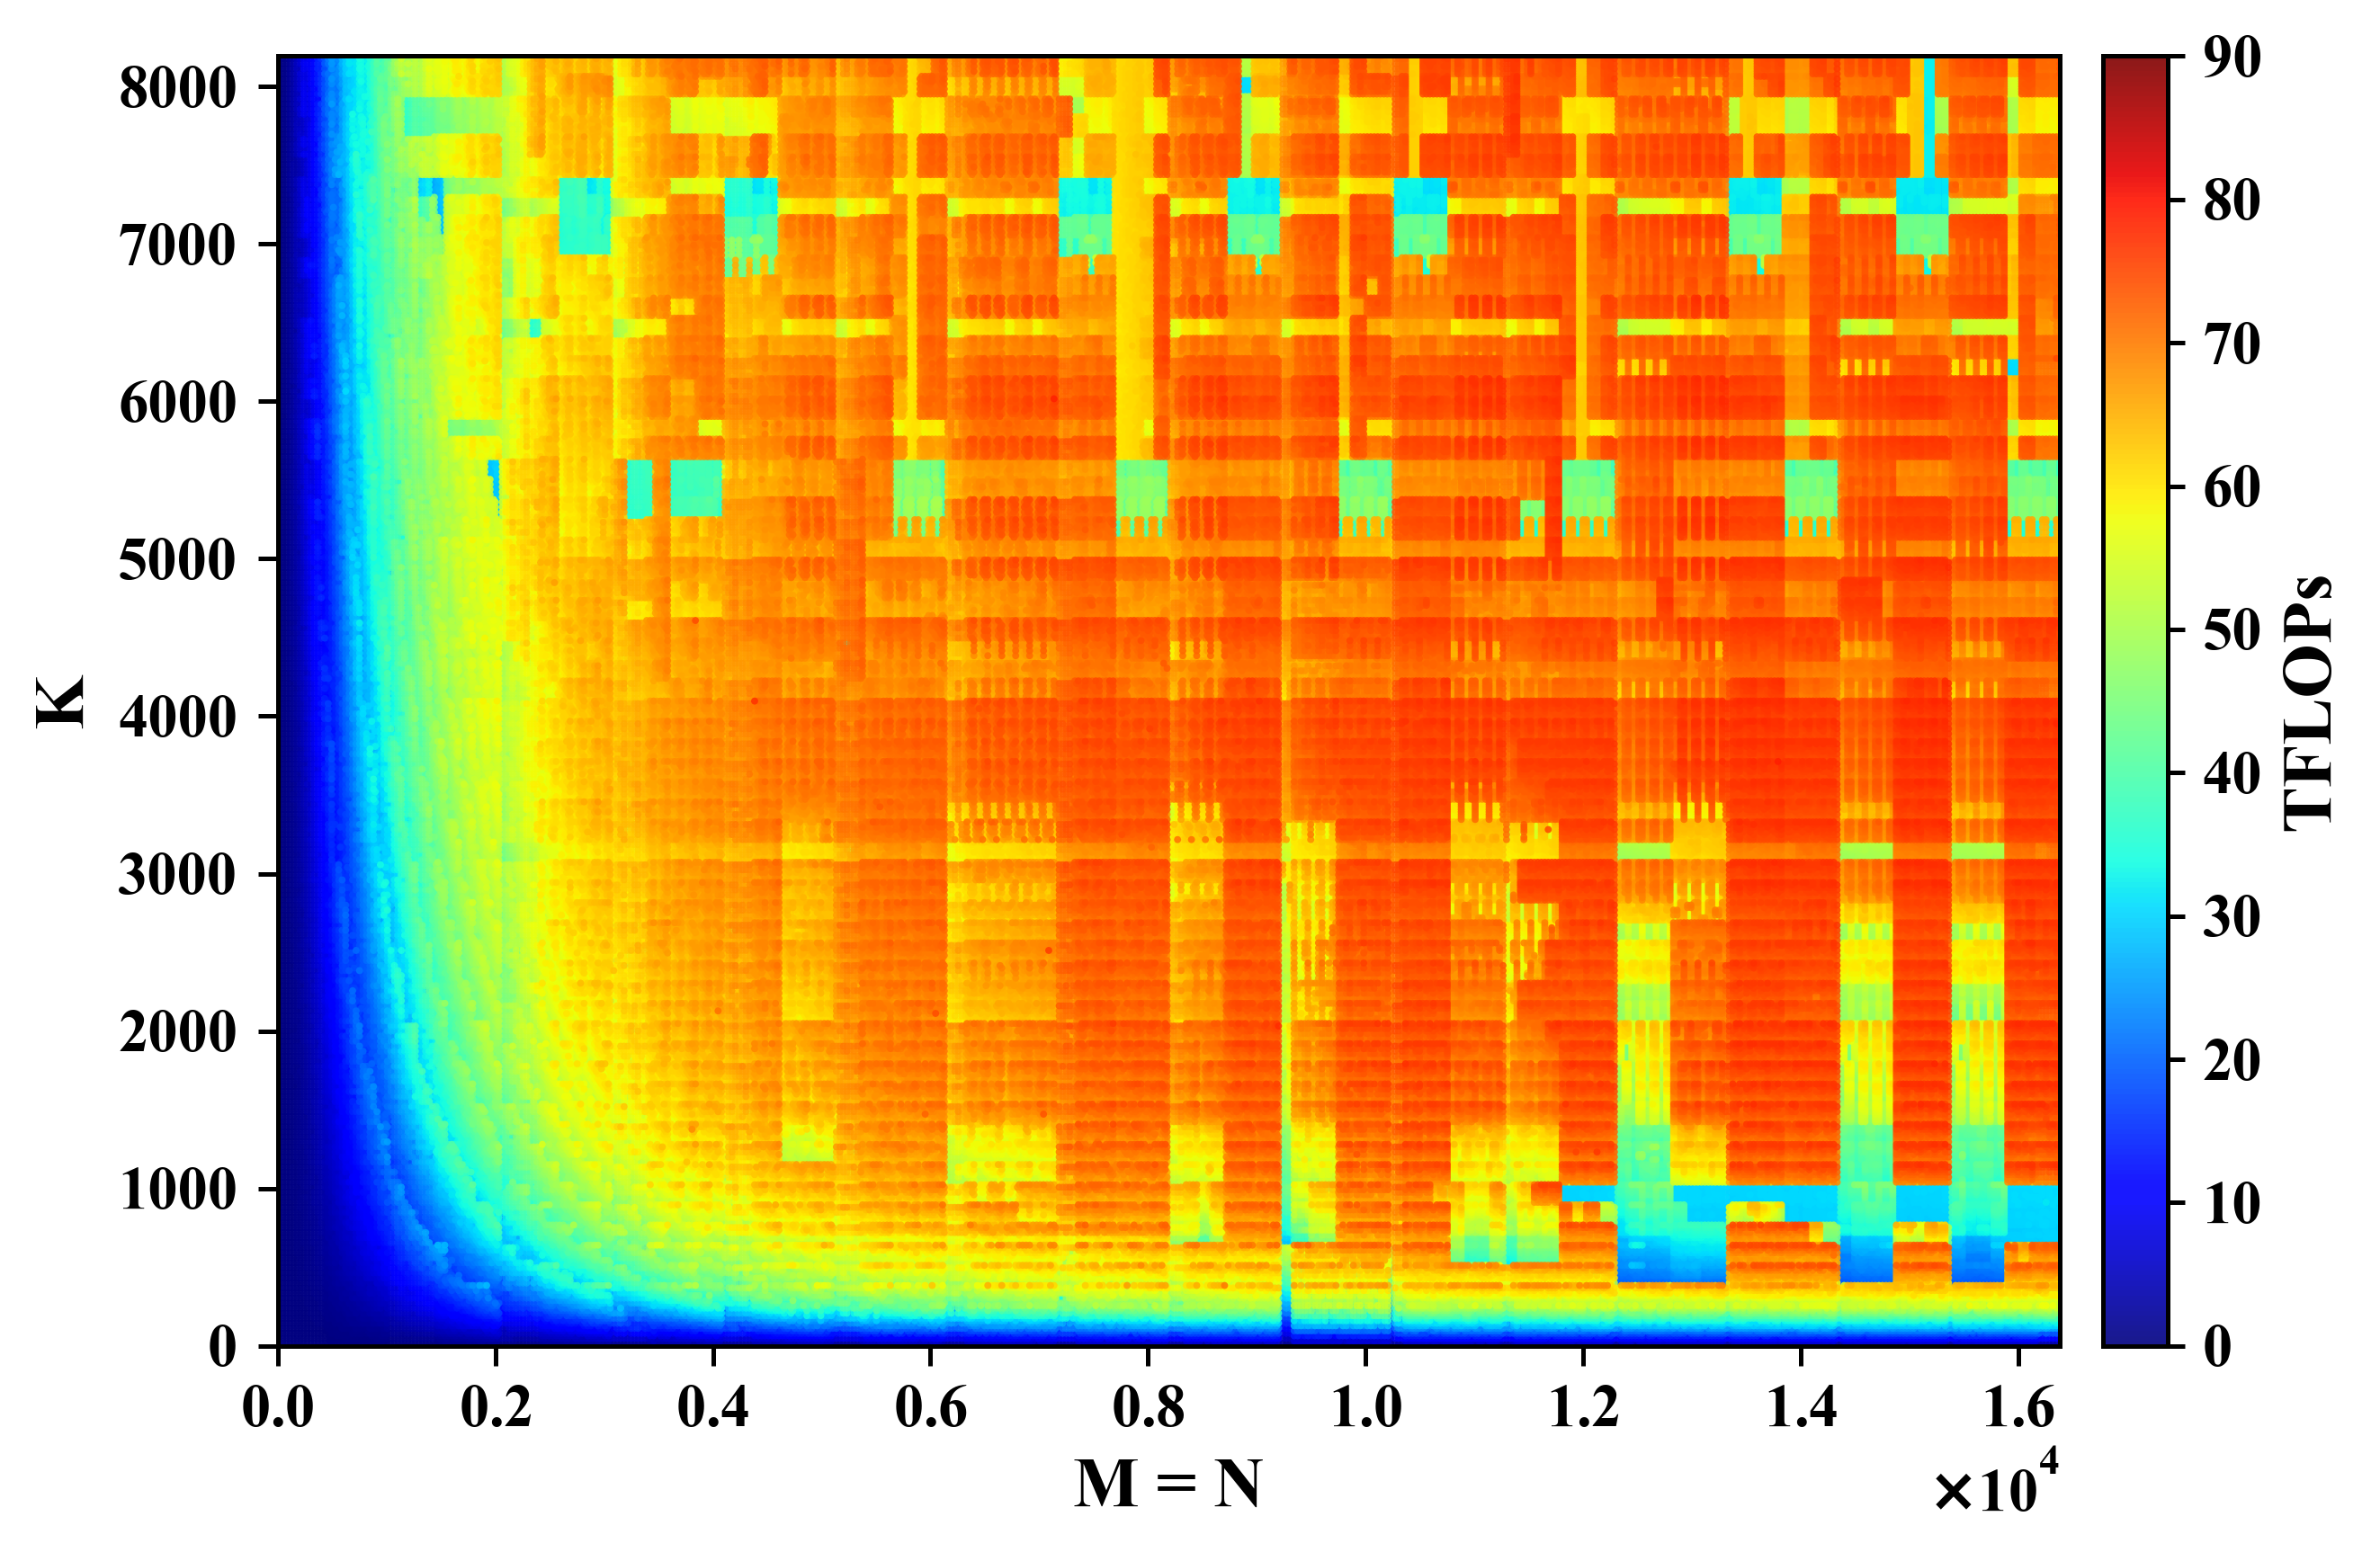

In [82]:
# Cell 3: Scatter "heatmap" (points colored by TFLOPS) — closest to your screenshot
plt.rcParams.update(
    {
        "font.size": 12,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 0.9,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
        "font.weight": "bold",
    }
)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=400)

sc = ax.scatter(
    data["M"].to_numpy(),
    data["K"].to_numpy(),
    c=data["avg_tflops"].to_numpy(),
    s=POINT_SIZE,
    alpha=ALPHA,
    cmap=CMAP,
    vmin=V_MIN,
    vmax=V_MAX,
    linewidths=0,
    rasterized=True,  # makes huge point clouds much lighter in vector outputs
)

ax.set_xlabel("M = N", fontweight="bold", fontsize=14)
ax.set_ylabel("K", fontweight="bold", fontsize=14)

# Format x-axis like "×10^5"
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0), useMathText=True)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("TFLOPs", fontweight="bold", fontsize=14)

ax.grid(False)
ax.set_xlim(left=0, right=data["M"].max())
ax.set_ylim(bottom=0, top=data["K"].max())

ax.tick_params(axis="y", length=4, pad=4)
ax.tick_params(axis="x", length=4, pad=4)

plt.tight_layout()
plt.show()

fig.savefig(
    "CharacterizationComputeHeatmap.pdf",
    bbox_inches="tight",
    dpi=400,
)

[[ 1  2  2  2  2  2]
 [ 1  1  2  2  2  2]
 [ 1  1  1  2  2  2]
 [ 1  1  1  1  2  2]
 [-1  1  1  1  1  2]
 [-1  1  1  1  1  1]]


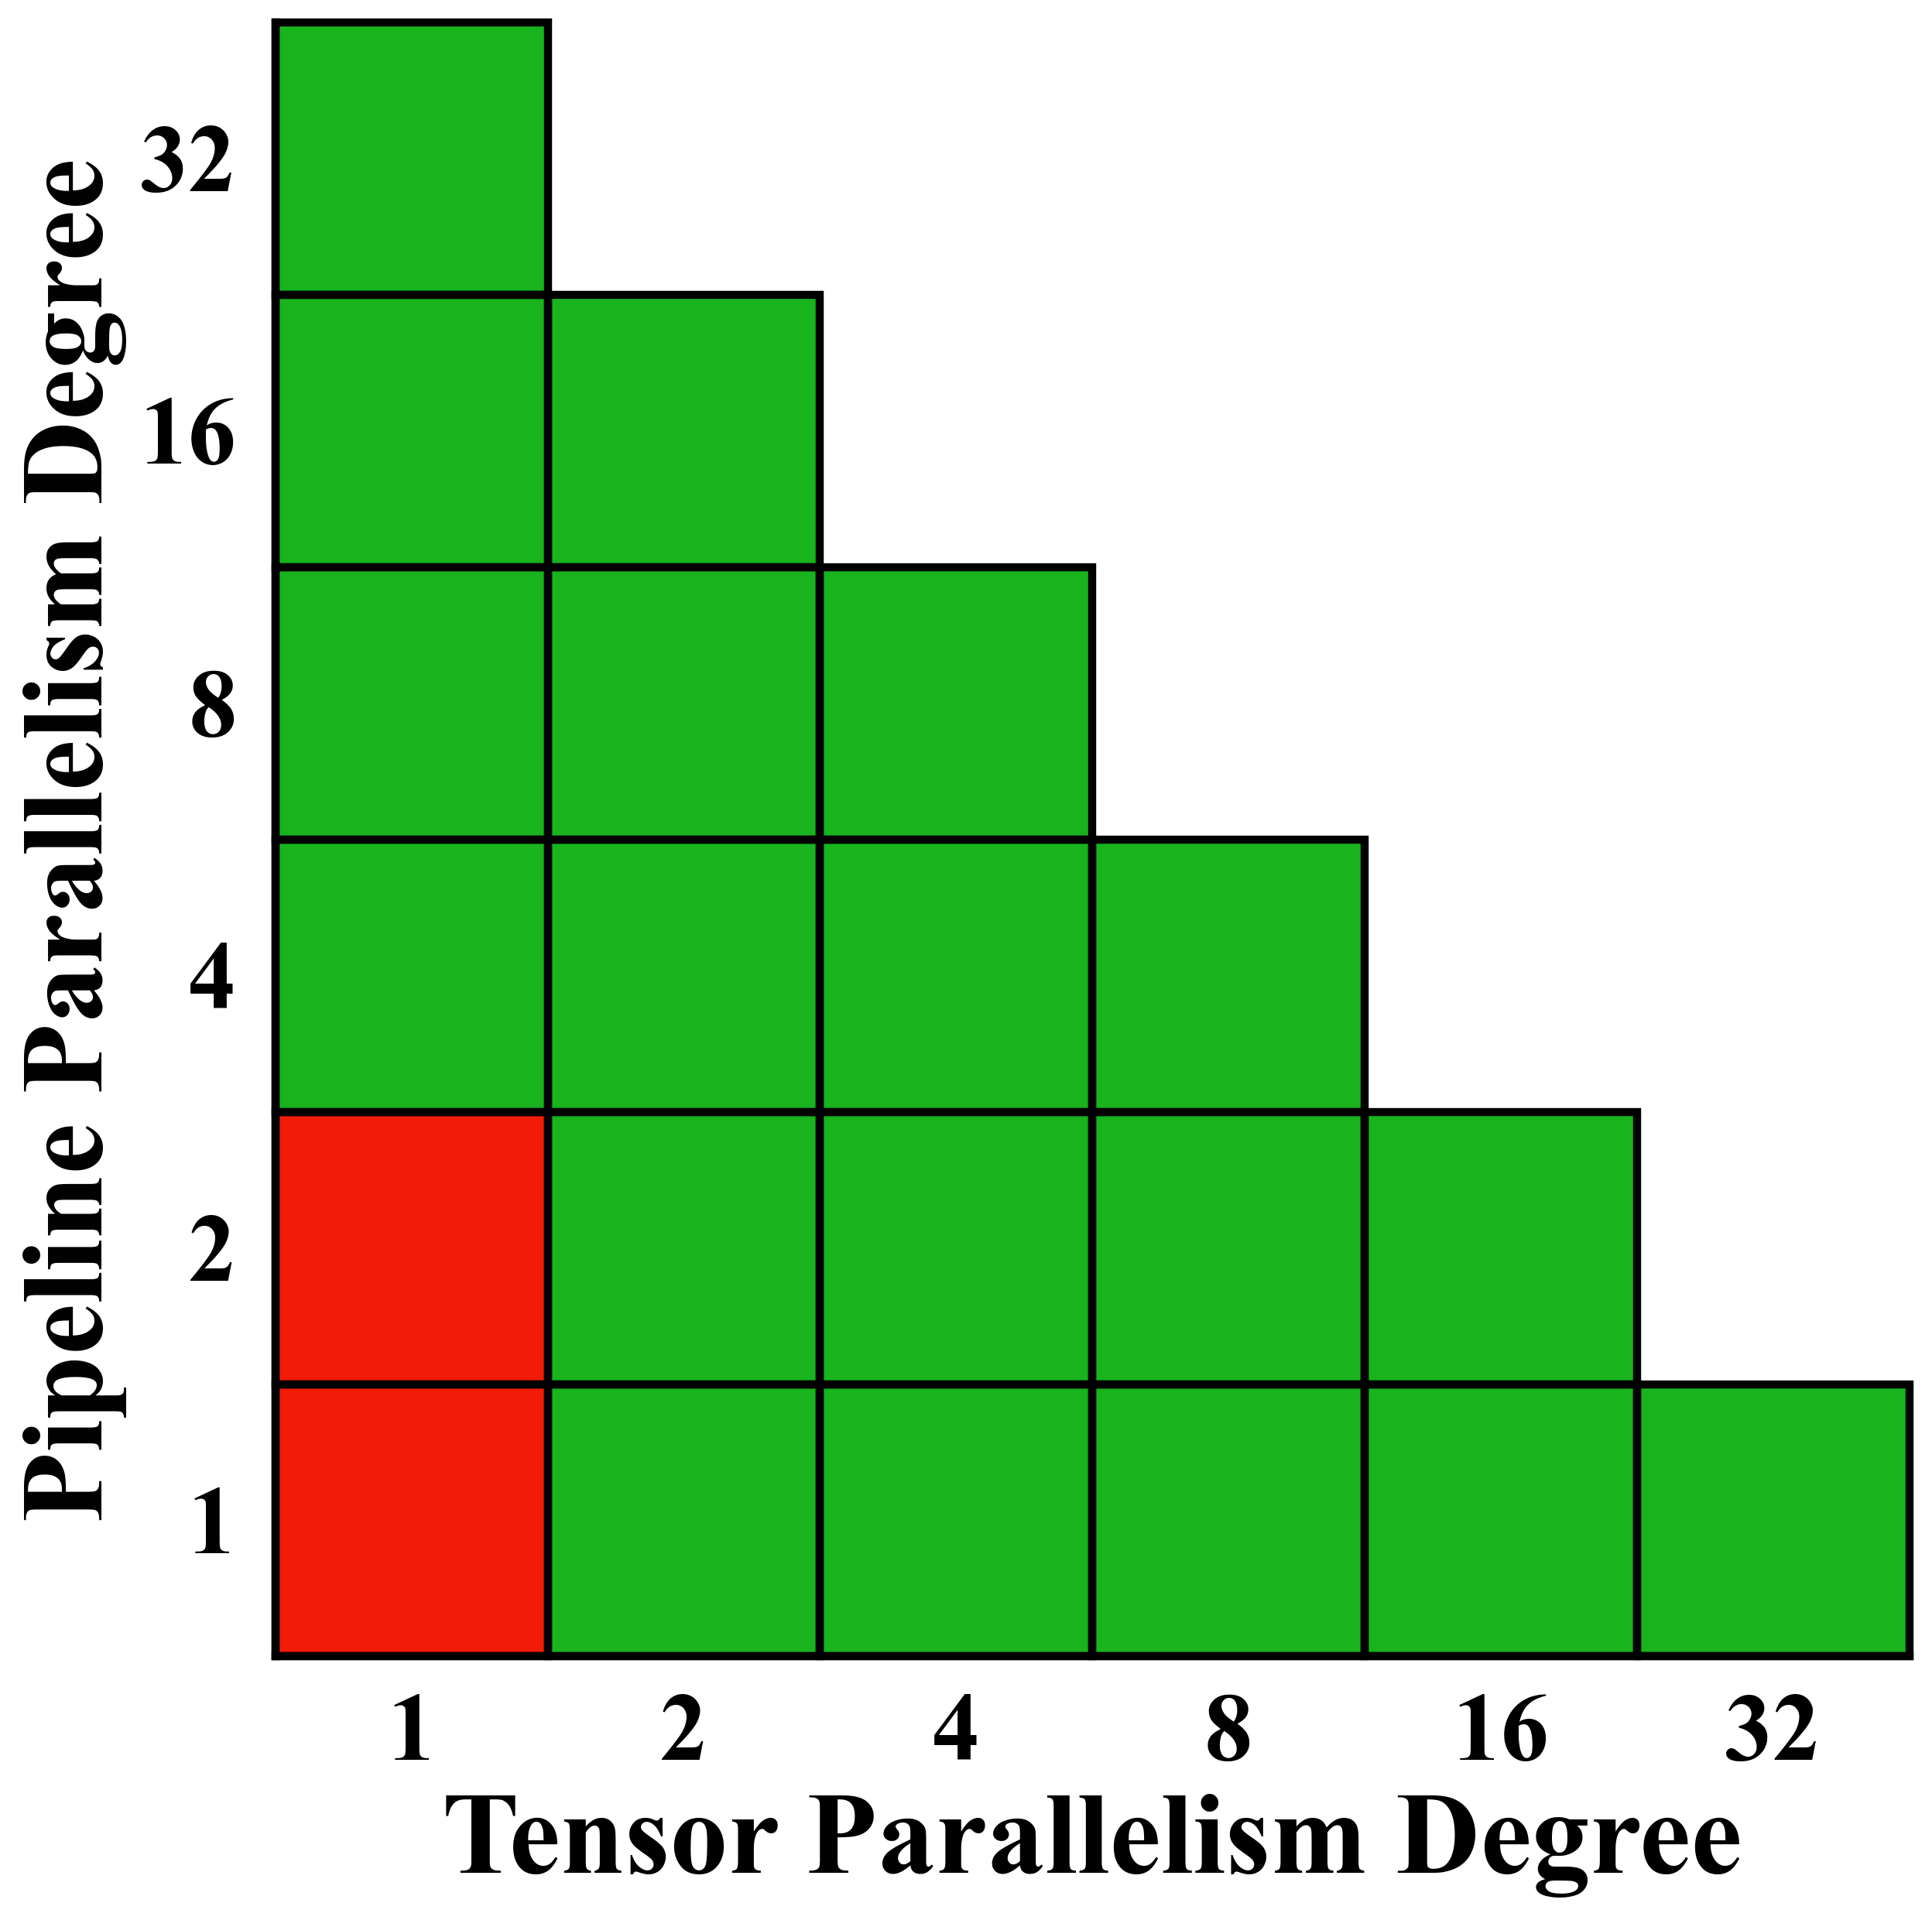

In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import numpy as np

plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

# --- 1. SETUP DATA ---
tp = [2**i for i in range(6)]
tp = tp[::-1]
pipeline = [2**i for i in range(6)]

data = np.zeros((6, 6))
for i in range(len(data)):
    for j in range(len(data[i])):
        # dp = 32 // (pipeline[j] * tp[i]) # Unused variable
        if pipeline[j] * tp[i] == 16:
            data[i][j] = -1
        if pipeline[j] * tp[i] == 32:
            data[i][j] = -1
        if tp[i] == 1:
            data[i][j] = -1
        # data[i][j] = -1
        if pipeline[j] * tp[i] > 32:
            # This is the value for WHITE squares
            data[i][j] = 2

# Before
# data = np.array(
#     [
#         [-1, 2, 2, 2, 2, 2],
#         [-1, -1, 2, 2, 2, 2],
#         [-1, -1, -1, 2, 2, 2],
#         [1, 1, -1, 1, 2, 2],
#         [-1, -1, -1, -1, -1, 2],
#         [-1, -1, -1, 1, -1, 1],
#     ]
# )
# print(data)

# After
# data[0][0] = 1
# data[2][2] = 1
# data[5][0] = 1
# data[5][2] = 1
# data[4][2] = 1
# data[2][0] = 1
# data[4][0] = -1
# data[4][1] = -1
# data[3][0] = -1
# data[3][1] = -1
# data = np.flip(np.transpose(data))
# # TODO rerun these ones
# data[4][4] = 1  # linshu
# data[2][2] = 1  # linshu
# data[5][4] = 1  # linshu
# data[4][3] = 1  # linshu
# data[2][1] = 1  # linshu
# data[5][2] = 1  # linshu
# data[4][2] = 1  # linshu
# data[1][1] = 1  # linshu
# data[5][1] = 1  # linshu
# # I ran
# data[3][2] = 1
# # data[2][0] = 1
# data[0][0] = 1
# data[1][0] = 1
data = np.array(
    [
        [1, 2, 2, 2, 2, 2],
        [1, 1, 2, 2, 2, 2],
        [1, 1, 1, 2, 2, 2],
        [1, 1, 1, 1, 2, 2],
        [-1, 1, 1, 1, 1, 2],
        [-1, 1, 1, 1, 1, 1],
    ]
)
print(data)

# np.transpose(data)

# --- 2. DEFINE COLORS & THRESHOLDS ---
# Define your 3 specific colors
# red = low values, yellow = mid values, green = high values, white = out of bounds
cmap = mcolors.ListedColormap(
    ["#F11B08", "#7A7A78", "#18B31D", "#FFFFFF"]
)  # Red, Gray, Green, White

# Define the boundaries (buckets)
# -1.5 to -0.5 -> Red   (value -1)
# -0.5 to  0.5 -> Gray  (value 0)
#  0.5 to  1.5 -> Green (value 1)
#  1.5 to  3.0 -> White (value 2)
bounds = [-1.5, -0.5, 0.5, 1.5, 3]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --- 3. CREATE PLOT ---
fig, ax = plt.subplots(figsize=(9, 9), dpi=300)

# Plot using the custom cmap and norm
im = ax.imshow(data, cmap=cmap, norm=norm)

# --- 4. FORMATTING ---
ax.set_xticks(np.arange(len(pipeline)))
ax.set_yticks(np.arange(len(tp)))
ax.set_xticklabels(pipeline, fontweight="bold")
ax.set_yticklabels(tp, fontweight="bold")

# Rotate x-labels
# plt.setp(
#     ax.get_xticklabels(),
#     rotation=45,
#     ha="right",
#     rotation_mode="anchor",
# )

# --- 5. TEXT ANNOTATIONS (Skipped as in original code) ---

# --- 6. ADD GRID LINES (MODIFIED) ---
# Instead of using ax.grid(), we manually draw rectangles around
# only the squares that are NOT white.

rows, cols = data.shape
for i in range(rows):
    for j in range(cols):
        # Check if the square is NOT white (value 2 corresponds to white)
        if data[i, j] != 2:
            # Create a Rectangle patch centered at (j, i)
            # The bottom-left corner is at (j - 0.5, i - 0.5)
            rect = patches.Rectangle(
                (j - 0.5, i - 0.5),  # xy (bottom-left)
                1,  # width
                1,  # height
                linewidth=2.5,  # line width matching original
                edgecolor="black",  # line color
                facecolor="none",  # transparent inside
            )
            rect.set_clip_on(False)
            # Add the patch to the Axes
            ax.add_patch(rect)

# Remove outer spine for cleaner look
# for edge, spine in ax.spines.items():
#     spine.set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Hide all tick marks
ax.tick_params(which="both", bottom=False, left=False)

ax.tick_params(axis="y", length=6, pad=6)
ax.tick_params(axis="x", length=6, pad=6)

ax.set_xlabel(
    "Tensor Parallelism Degree",
    fontsize=36,
    fontweight="bold",
    labelpad=4,
)
ax.set_ylabel(
    "Pipeline Parallelism Degree",
    fontsize=36,
    fontweight="bold",
    labelpad=4,
)

# oom_locations = [
#     (4, 0),
#     (4, 1),
# ]
# h_oom_locations = [
#     [2, 0],
# ]
# con_locations = [
#     # (2,0),
#     (1, 0),
#     (0, 0),
#     (2, 1),
#     (1, 1),
#     (4, 2),
#     (3, 2),
#     (2, 2),
#     (4, 3),
#     (4, 4),
#     (5, 1),
#     (5, 2),
#     (5, 4),
# ]



# for r, c in oom_locations:
#     # Ensure coordinates are within bounds
#     if 0 <= r < rows and 0 <= c < cols:
#         ax.text(c, r, "SIGKILL",
#                 ha="center", va="center",
#                 color="black",      # Change to 'white' if placing on dark squares
#                 fontsize=14,        # Adjust size
#                 fontweight='normal')
# for r, c in h_oom_locations:
#     # Ensure coordinates are within bounds
#     if 0 <= r < rows and 0 <= c < cols:
#         ax.text(c, r, "DESC",
#                 ha="center", va="center",
#                 color="black",      # Change to 'white' if placing on dark squares
#                 fontsize=14,        # Adjust size
#                 fontweight='normal')
# for r, c in con_locations:
#     # Ensure coordinates are within bounds
#     if 0 <= r < rows and 0 <= c < cols:
#         ax.text(c, r, "CON",
#                 ha="center", va="center",
#                 color="black",      # Change to 'white' if placing on dark squares
#                 fontsize=14,        # Adjust size
#                 fontweight='normal')
plt.tight_layout()
plt.show()

fig.savefig(
    # "EvaluationCompatibilityBefore.pdf",
    "EvaluationCompatibilityAfter.pdf",
    bbox_inches="tight",
    dpi=300,
)

[[  0.88    nan    nan    nan    nan    nan]
 [  0.57   8.86    nan    nan    nan    nan]
 [  0.66  28.3   28.64    nan    nan    nan]
 [  0.65  21.92  48.72  48.7     nan    nan]
 [   nan  45.71  27.92 103.41   0.53    nan]
 [   nan   8.8   29.    49.02   0.53   0.38]]


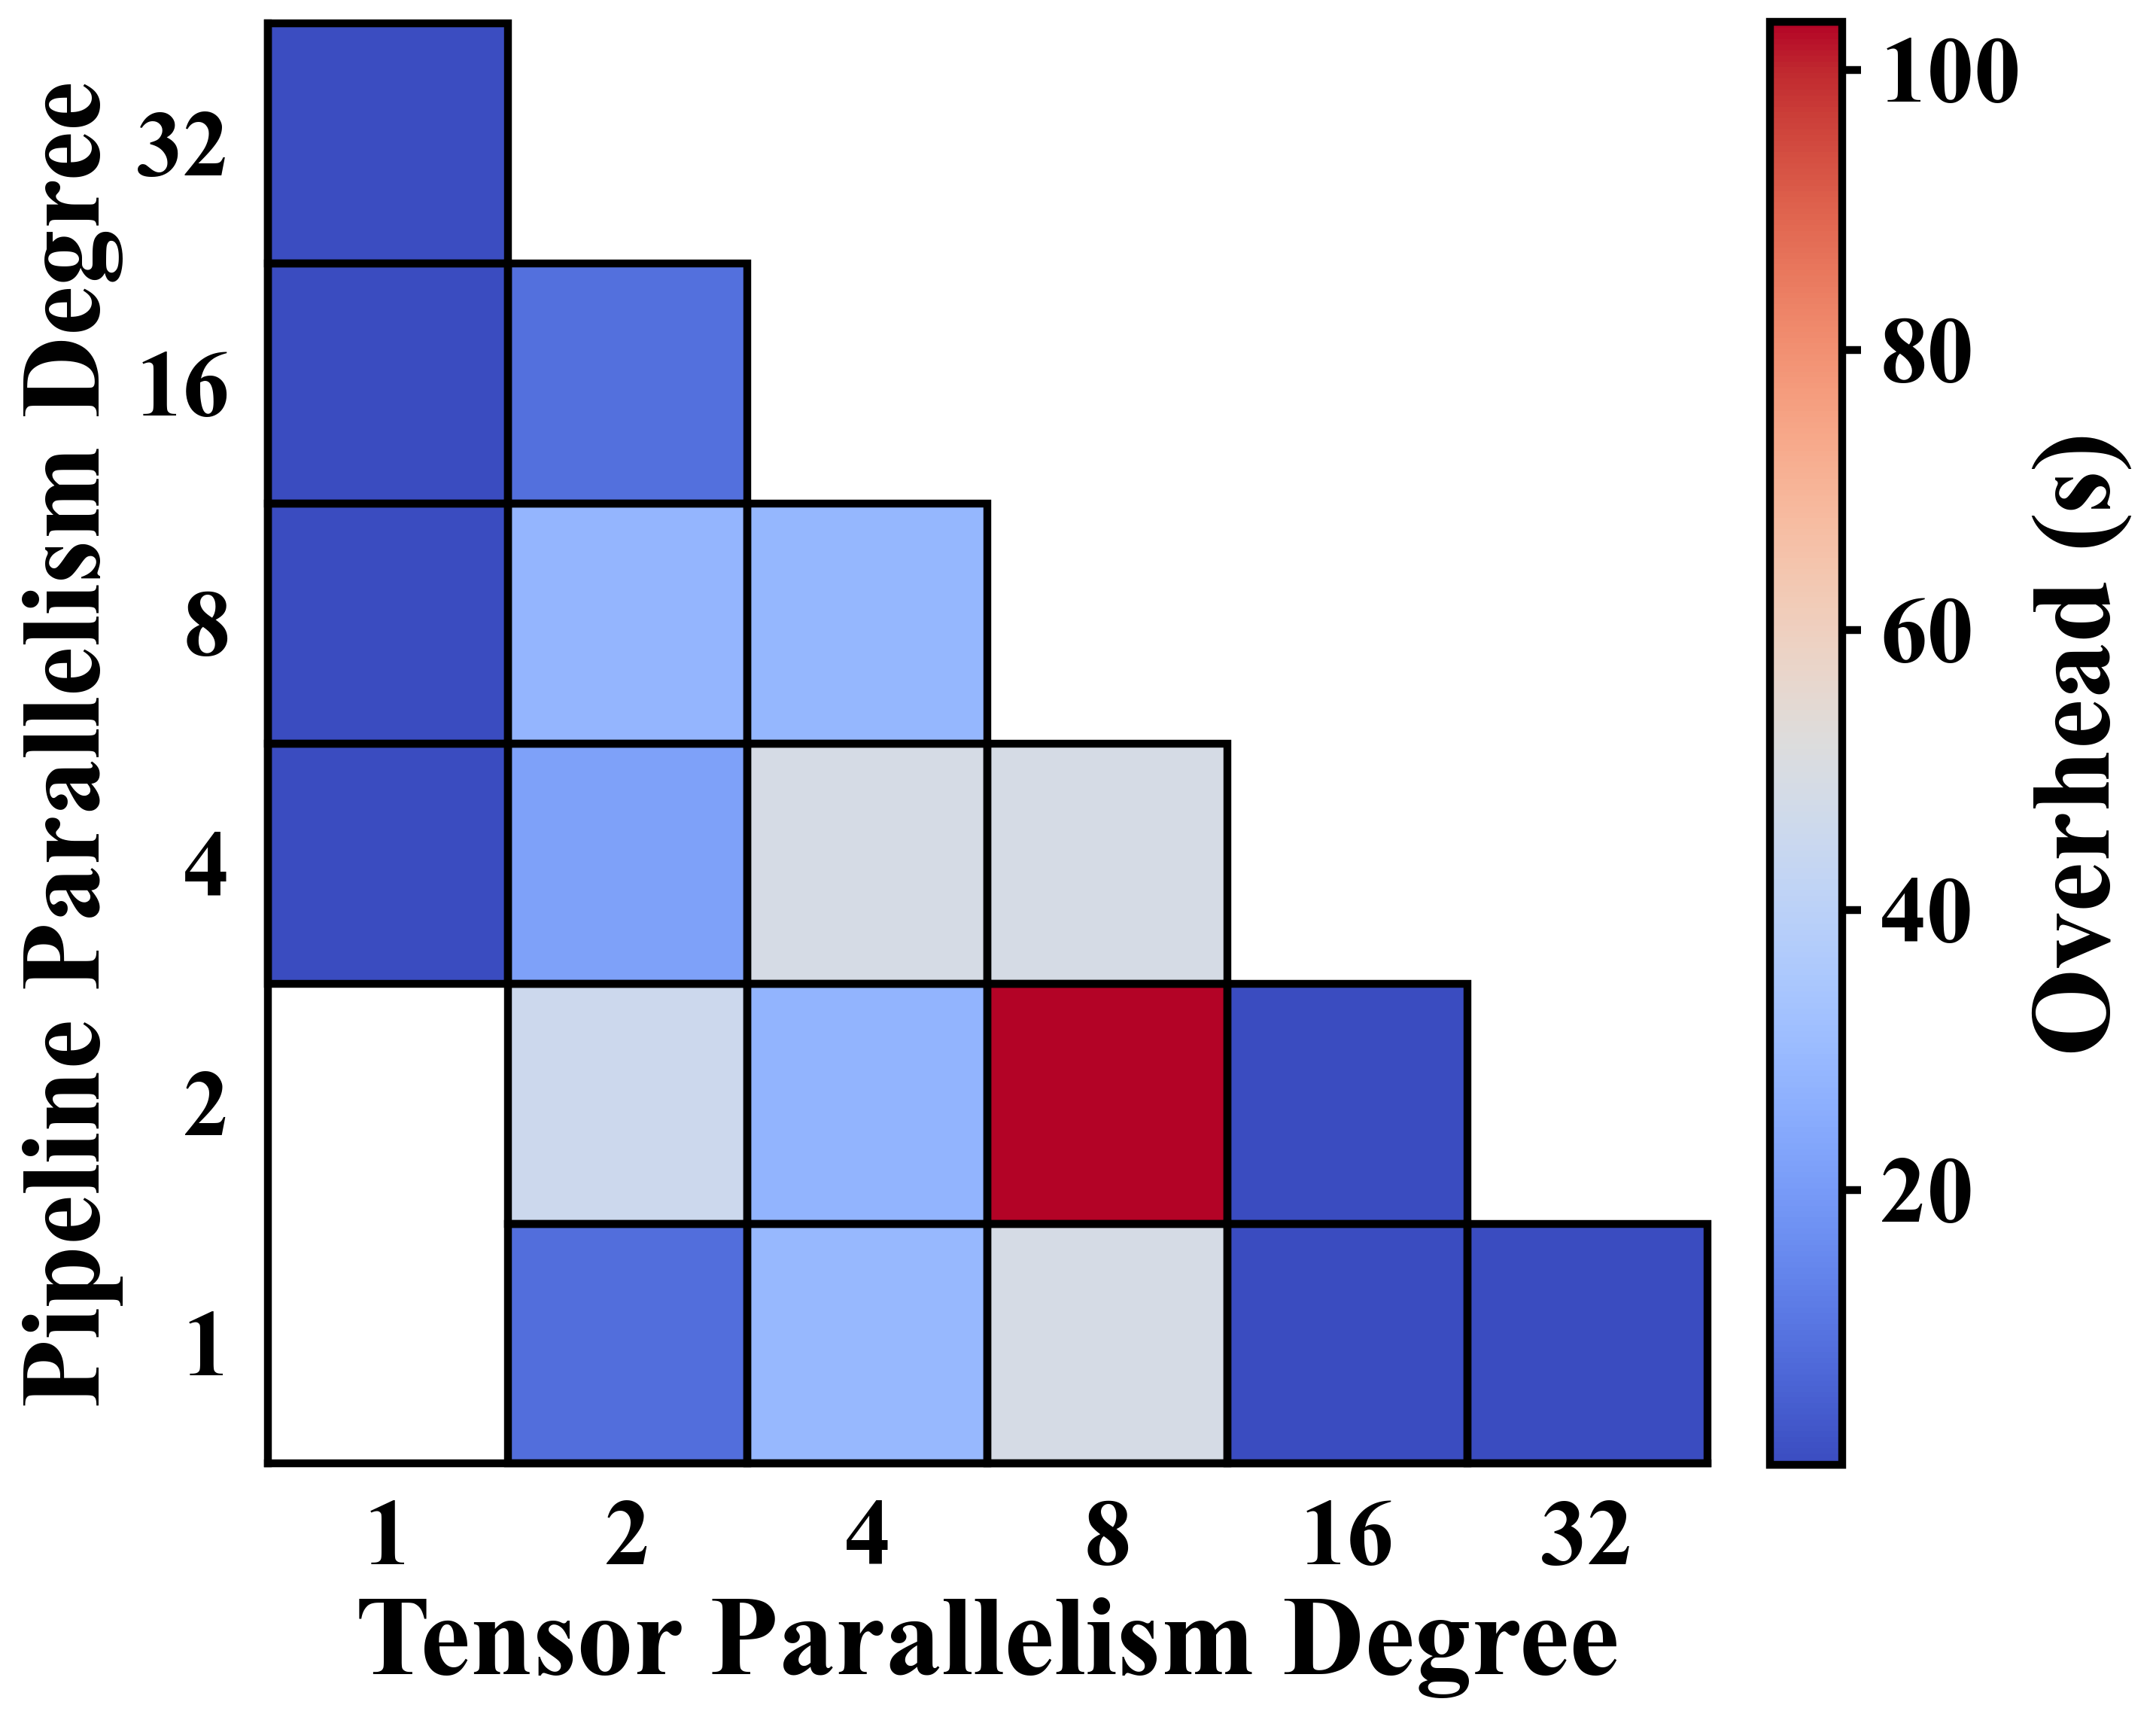

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import numpy as np

plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": plt.rcParams["font.sans-serif"][0],
        "axes.linewidth": 2.5,
        "xtick.major.width": 2.5,
        "ytick.major.width": 2.5,
    }
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman"],
    }
)

# --- 1. SETUP DATA ---
tp = [2**i for i in range(6)][::-1]   # y-axis labels
pipeline = [2**i for i in range(6)]   # x-axis labels

# Use NaN for invalid / white cells
data = np.full((6, 6), np.nan, dtype=float)

# Example: fill valid region with float values
# Replace these with your real float measurements
example_values = np.array(
    [
        [0.88, np.nan, np.nan, np.nan, np.nan, np.nan],
        [0.57, 8.86, np.nan, np.nan, np.nan, np.nan],
        [0.66, 28.30, 28.64, np.nan, np.nan, np.nan],
        [0.65, 21.92, 48.72, 48.70, np.nan, np.nan],
        [np.nan, 45.71, 27.92, 103.41, 0.53, np.nan],
        [np.nan, 8.80, 29.00, 49.02, 0.53, 0.38],
    ],
    dtype=float,
)
data[:, :] = example_values

print(data)

# --- 2. DEFINE COLORMAP ---
# Pick a continuous colormap
cmap = plt.cm.coolwarm.copy()   # low=red, high=green
cmap.set_bad(color="white")   # NaN cells appear white

# Normalize based on the valid float range
vmin = np.nanmin(data)
vmax = np.nanmax(data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- 3. CREATE PLOT ---
fig, ax = plt.subplots(figsize=(9, 9), dpi=300)

im = ax.imshow(data, cmap=cmap, norm=norm)

# Optional colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.0458, pad=0.04)
cbar.ax.tick_params(labelsize=30, width=2.5, length=6, pad=6)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")
cbar.outline.set_linewidth(2.5)
cbar.set_label("Overhead (s)", fontsize=36, fontweight="bold")

# --- 4. FORMATTING ---
ax.set_xticks(np.arange(len(pipeline)))
ax.set_yticks(np.arange(len(tp)))
ax.set_xticklabels(pipeline, fontweight="bold")
ax.set_yticklabels(tp, fontweight="bold")

# --- 5. ADD GRID RECTANGLES ONLY FOR VALID CELLS ---
rows, cols = data.shape
for i in range(rows):
    for j in range(cols):
        if not np.isnan(data[i, j]):
            rect = patches.Rectangle(
                (j - 0.5, i - 0.5),
                1,
                1,
                linewidth=2.5,
                edgecolor="black",
                facecolor="none",
            )
            rect.set_clip_on(False)
            ax.add_patch(rect)

# Optional: annotate each valid cell with its numeric value
# for i in range(rows):
#     for j in range(cols):
#         if not np.isnan(data[i, j]):
#             ax.text(
#                 j, i, f"{data[i, j]:.2f}",
#                 ha="center", va="center",
#                 color="black", fontsize=14
#             )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(which="both", bottom=False, left=False)
ax.tick_params(axis="y", length=6, pad=6)
ax.tick_params(axis="x", length=6, pad=6)

ax.set_xlabel(
    "Tensor Parallelism Degree",
    fontsize=36,
    fontweight="bold",
    labelpad=4,
)
ax.set_ylabel(
    "Pipeline Parallelism Degree",
    fontsize=36,
    fontweight="bold",
    labelpad=4,
)

# plt.tight_layout()
plt.show()

fig.savefig(
    "EvaluationPlanningOverhead.pdf",
    bbox_inches="tight",
    dpi=300,
)